# 3. Bundle-priced EIP-7999 equilibrium

This notebook reproduces the equilibrium, fee-floor frontier, capacity
grid, and robustness results in
`markdowns/bundle_priced_7999_equilibrium_report.md`.

It consumes the compact handoffs produced by notebooks 01 and 02 in this
folder. The execution and state metering multipliers in the notebook-02
demand card are derived by
[`../resource_demand_and_glamsterdam_equilibrium/02-metering-multipliers.ipynb`](../resource_demand_and_glamsterdam_equilibrium/02-metering-multipliers.ipynb),
and the execution, data, and state elasticity vectors are derived by
[`../resource_demand_and_glamsterdam_equilibrium/03-demand-model-elasticity.ipynb`](../resource_demand_and_glamsterdam_equilibrium/03-demand-model-elasticity.ipynb).
This notebook uses those upstream estimates rather than re-estimating them.
The active-set solver evaluates all
eight possible fee-floor pin sets and requires one economically distinct
equilibrium.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.optimize import brentq, root


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_DIR = PROJECT_ROOT / "data"
INPUT_DIR = DATA_DIR / "7999"
PLOTS_DIR = PROJECT_ROOT / "plots"
PLOTS_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14,
    "xtick.labelsize": 14, "ytick.labelsize": 14,
    "legend.fontsize": 14, "figure.titlesize": 18,
})
plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.6f}".format

DATE_LABEL = "2026-02-01_2026-06-01"
GWEI = 1e9
MIN_FEE_WEI = 1.0
CENTRAL_WINDOW = 35
CENTRAL_LAMBDA = 0.0
RHO_A_GRID = [0.75, 1.0, 1.25]
RESOURCES = ("execution", "data", "state")

metering_path = INPUT_DIR / "data_metering_runtime_bal_anchor.csv"
demand_path = INPUT_DIR / "bal_decomposition_demand_parameters.csv"
missing = [str(path) for path in (metering_path, demand_path) if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run notebooks 01 and 02 before solving the equilibrium:\n- "
        + "\n- ".join(missing)
    )
metering = pd.read_csv(metering_path).iloc[0]
demand = pd.read_csv(demand_path).iloc[0]

# These vectors are estimated by the resource-demand notebook 03. Keep the
# published values as a reproducible fallback and verify its handoff when present.
published_elasticities = pd.DataFrame([
    {"window_days": 21, "eps_execution": 0.1170668159071278, "eps_data": 0.2017901574997101, "eps_state": 0.4784376616162406},
    {"window_days": 35, "eps_execution": 0.1211596378167212, "eps_data": 0.2294762749968381, "eps_state": 0.3348638470580465},
    {"window_days": 60, "eps_execution": 0.0816682106235291, "eps_data": 0.2046910570850992, "eps_state": 0.279675525753271},
    {"window_days": 75, "eps_execution": 0.0785108223582338, "eps_data": 0.2013910565486362, "eps_state": 0.253555905620326},
])
glam_elasticities_path = DATA_DIR / "glamsterdam" / "elasticity_vectors.csv"
if glam_elasticities_path.exists():
    elasticities = pd.read_csv(glam_elasticities_path).sort_values("window_days")
    for column in ["eps_execution", "eps_data", "eps_state"]:
        if not np.allclose(
            elasticities[column], published_elasticities[column], rtol=5e-6, atol=5e-7
        ):
            raise AssertionError(f"shared elasticity input changed for {column}")
else:
    elasticities = published_elasticities

WINDOW_DAYS = elasticities["window_days"].astype(int).tolist()
EPS_BY_WINDOW = {
    int(row.window_days): {
        "execution": float(row.eps_execution),
        "data": float(row.eps_data),
        "state": float(row.eps_state),
    }
    for row in elasticities.itertuples(index=False)
}
EPS = EPS_BY_WINDOW[CENTRAL_WINDOW]

p0 = float(demand["base_fee_ref_gwei"])
# The demand card carries the execution/state metering multipliers derived by
# the resource-demand notebook 02; this notebook does not recalibrate them.
m_execution = float(demand["m_execution"])
m_state = float(demand["m_state"])
m_data = float(metering["static_data_metering_multiplier"])
q_execution_0 = float(demand["q_execution_per_block"])
q_state_0 = float(demand["q_state_per_block"])
g_static_0 = float(metering["static_data_gas_per_block"])
g_bal_0 = float(metering["runtime_bal_data_gas_per_block"])
d_share = float(demand["bal_direct_state_weight"])
c_share = float(demand["bal_coproduced_state_transaction_weight"])
n_share = float(demand["bal_nonstate_transaction_weight"])
CENTRAL_RHO_A = float(demand["rho_A_reference"])
STATE_TARGET = 75_000_000.0

# The paired capacity path preserves the historical data/execution ratio.
headline = pd.DataFrame([
    {"execution_gas_limit": 272_567_184, "data_gas_target": 15_000_000},
    {"execution_gas_limit": 327_080_621, "data_gas_target": 18_000_000},
    {"execution_gas_limit": 408_850_776, "data_gas_target": 22_500_000},
    {"execution_gas_limit": 545_134_368, "data_gas_target": 30_000_000},
])

EPS


{'execution': 0.1211596378167212,
 'data': 0.2294762749968381,
 'state': 0.3348638470580465}

## BAL intensities

The anchor intensities are data gas mechanically produced per historical gas-equivalent unit of
parent activity:

$$
w_{\mathrm{execution}}(\lambda) = \frac{\omega_{\mathrm{execution}}(\lambda)\,g_{\mathrm{BAL}}^0}{q_{\mathrm{execution}}^0},
\qquad
w_{\mathrm{state}}(\lambda) = \frac{\omega_{\mathrm{state}}(\lambda)\,g_{\mathrm{BAL}}^0}{q_{\mathrm{state}}^0},
\qquad
\omega_{\mathrm{state}} = d + \lambda c,\quad \omega_{\mathrm{execution}} = n + (1-\lambda)c .
$$

Away from the anchor, existing-state access is allowed to scale as
$A/A^0=(q_{\mathrm{execution}}/q_{\mathrm{execution}}^0)^{\rho_A}$. The average execution-linked BAL
intensity is therefore $\bar w_{\mathrm{execution}}=w_{\mathrm{execution}}
(q_{\mathrm{execution}}/q_{\mathrm{execution}}^0)^{\rho_A-1}$. At the anchor, and whenever
$\rho_A=1$, $\bar w_{\mathrm{execution}}=w_{\mathrm{execution}}$.

In [2]:
def intensities(lambda_bal):
    omega_state = d_share + lambda_bal * c_share
    omega_execution = n_share + (1.0 - lambda_bal) * c_share
    return (
        omega_execution * g_bal_0 / q_execution_0,   # w_e
        omega_state * g_bal_0 / q_state_0,           # w_s
    )

def execution_bal_intensity(q_execution, lambda_bal, rho_A):
    w_e, _ = intensities(lambda_bal)
    return w_e * (q_execution / q_execution_0) ** (rho_A - 1.0)

def bal_components(q_execution, q_state, lambda_bal, rho_A):
    w_e, w_s = intensities(lambda_bal)
    execution_ratio = q_execution / q_execution_0
    bal_execution = w_e * q_execution_0 * execution_ratio ** rho_A
    bal_state = w_s * q_state
    return bal_execution, bal_state

LAMBDA_GRID = [0.0, 0.5, 1.0]
intensity_table = pd.DataFrame(
    [
        dict(zip(["w_execution", "w_state"], intensities(lam)), lambda_bal=lam)
        for lam in LAMBDA_GRID
    ]
).set_index("lambda_bal")
intensity_table["w_execution / m_execution"] = (
    intensity_table["w_execution"] / m_execution
)
display(intensity_table)

w_e_central, w_s_central = intensities(CENTRAL_LAMBDA)
for label, got, want in [
    ("w_e", w_e_central, 0.0710),
    ("w_s", w_s_central, 0.0417),
    ("w_e / m_e", w_e_central / m_execution, 0.0462),
]:
    if abs(got - want) > 5e-4:
        raise AssertionError(f"{label} disagrees with the proposal note: {got:.6f} vs {want}")
# BAL and the measured execution intensity must be conserved at the anchor.
for lam in LAMBDA_GRID:
    w_e, _ = intensities(lam)
    for rho_A in RHO_A_GRID:
        bal_e, bal_s = bal_components(q_execution_0, q_state_0, lam, rho_A)
        if not np.isclose(bal_e + bal_s, g_bal_0, rtol=1e-12):
            raise AssertionError("BAL components must reproduce the anchor")
        if not np.isclose(execution_bal_intensity(q_execution_0, lam, rho_A), w_e):
            raise AssertionError("effective execution BAL intensity must match its anchor")
print("anchor BAL and execution intensity hold for every lambda x rho_A combination")

,w_execution,w_state,w_execution / m_execution
lambda_bal,,,
0.000000,0.071023,0.041695,0.046182
0.500000,0.055842,0.111005,0.036310
1.000000,0.040661,0.180314,0.026439


anchor BAL and execution intensity hold for every lambda x rho_A combination


## The model

Let $R_{\mathrm{execution}}=q_{\mathrm{execution}}/q_{\mathrm{execution}}^0$. The access proxy and
execution-linked BAL are

$$
\frac{A}{A^0}=R_{\mathrm{execution}}^{\rho_A},
\qquad
g_{\mathrm{BAL,execution}}=w_{\mathrm{execution}}q_{\mathrm{execution}}^0R_{\mathrm{execution}}^{\rho_A}.
$$

The average BAL charge per unit of execution is therefore based on
$\bar w_{\mathrm{execution}}(R_{\mathrm{execution}})=w_{\mathrm{execution}}R_{\mathrm{execution}}^{\rho_A-1}$:

$$
P_{\mathrm{execution}} = m_{\mathrm{execution}} b_{\mathrm{execution}} + \bar w_{\mathrm{execution}}(R_{\mathrm{execution}}) b_{\mathrm{data}},
\qquad
P_{\mathrm{state}} = m_{\mathrm{state}} b_{\mathrm{state}} + w_{\mathrm{state}} b_{\mathrm{data}},
\qquad
q_i = q_i^0\left(\frac{P_i}{p^0}\right)^{-\epsilon_i}
$$

$P_{\mathrm{execution}}$ and $P_{\mathrm{state}}$ are BAL-inclusive parent prices per historical
parent-activity unit. Their scope covers the parent-resource charge and assigned runtime-BAL
charge. Static transaction data and other transaction-level charges remain outside them.

Static data remains $g_{\mathrm{static}}^0
(m_{\mathrm{data,static}}b_{\mathrm{data}}/p^0)^{-\epsilon_{\mathrm{data}}}$, while total BAL is

$$
g_{\mathrm{BAL}}=w_{\mathrm{execution}}q_{\mathrm{execution}}^0R_{\mathrm{execution}}^{\rho_A}
+w_{\mathrm{state}}q_{\mathrm{state}}.
$$

Because $\bar w_{\mathrm{execution}}$ depends on realized execution, the execution demand equation is
implicit. It is solved as a one-dimensional root in $\log R_{\mathrm{execution}}$ inside each fee
evaluation. $\rho_A=1$ recovers the original linear model exactly.

Each resource either clears its target at a fee above one wei, or sits at one wei with usage below
target. The solver evaluates all eight pin sets, retains every complementarity-valid candidate,
collapses numerically identical boundary representations, and asserts that exactly one economic
equilibrium remains.

In [3]:
def execution_ratio(fees, eps, lambda_bal, rho_A):
    w_e, _ = intensities(lambda_bal)
    log_execution_charge = np.log(m_execution * fees["execution"])
    log_bal_charge = np.log(w_e * fees["data"])
    log_p0 = np.log(p0)

    def log_residual(log_ratio):
        log_price = np.logaddexp(
            log_execution_charge, log_bal_charge + (rho_A - 1.0) * log_ratio
        )
        return log_ratio + eps["execution"] * (log_price - log_p0)

    log_ratio = brentq(log_residual, -80.0, 80.0, xtol=1e-13, rtol=1e-13)
    return np.exp(log_ratio)

def quantities(fees, eps, lambda_bal, rho_A=CENTRAL_RHO_A):
    _, w_s = intensities(lambda_bal)
    ratio_execution = execution_ratio(fees, eps, lambda_bal, rho_A)
    q_execution = q_execution_0 * ratio_execution
    price_state = m_state * fees["state"] + w_s * fees["data"]
    q_state = q_state_0 * (price_state / p0) ** (-eps["state"])
    g_static = g_static_0 * (m_data * fees["data"] / p0) ** (-eps["data"])
    return q_execution, q_state, g_static

def resource_usage(fees, eps, lambda_bal, rho_A=CENTRAL_RHO_A):
    q_execution, q_state, g_static = quantities(fees, eps, lambda_bal, rho_A)
    bal_execution, bal_state = bal_components(q_execution, q_state, lambda_bal, rho_A)
    return {
        "execution": m_execution * q_execution,
        "state": m_state * q_state,
        "data": g_static + bal_execution + bal_state,
    }

def _solve_with_pins(targets, eps, lambda_bal, rho_A, pinned):
    free = [r for r in RESOURCES if r not in pinned]

    def unpack(log_fees):
        out = {r: MIN_FEE_WEI / GWEI for r in RESOURCES}
        for resource, value in zip(free, np.exp(np.clip(log_fees, -80.0, 20.0))):
            out[resource] = value
        return out

    if not free:
        fees = unpack([])
        return fees, resource_usage(fees, eps, lambda_bal, rho_A), True

    def residual(log_fees):
        usage = resource_usage(unpack(log_fees), eps, lambda_bal, rho_A)
        return [np.log(max(usage[r], 1e-12) / targets[r]) for r in free]

    anchor = {"execution": p0 / m_execution, "data": p0 / m_data, "state": p0 / m_state}
    for scale in (1.0, 1e-2, 1e-4, 1e-7, 1e-11, 1e2):
        solution = root(
            residual, [np.log(anchor[r] * scale) for r in free], method="hybr", tol=1e-13
        )
        if bool(solution.success) and float(np.max(np.abs(residual(solution.x)))) < 1e-8:
            fees = unpack(solution.x)
            return fees, resource_usage(fees, eps, lambda_bal, rho_A), True
    fees = unpack(solution.x)
    return fees, resource_usage(fees, eps, lambda_bal, rho_A), False

FEE_FEASIBILITY_ATOL_WEI = 1e-6
TARGET_FEASIBILITY_RTOL = 1e-8
TARGET_FEASIBILITY_ATOL_GAS = 1.0
DEDUP_FEE_RTOL = 1e-9
DEDUP_FEE_ATOL_WEI = 1e-3
DEDUP_USAGE_RTOL = 1e-9
DEDUP_USAGE_ATOL_GAS = 1.0

def _candidate_diagnostics(fees, usage, targets, pinned):
    free = [r for r in RESOURCES if r not in pinned]
    fee_wei = {r: fees[r] * GWEI for r in RESOURCES}
    interior_residual_gas = [abs(usage[r] - targets[r]) for r in free]
    interior_residual_relative = [
        abs(usage[r] / targets[r] - 1.0) for r in free
    ]
    complementarity = [
        abs((fee_wei[r] - MIN_FEE_WEI) * (targets[r] - usage[r]))
        for r in RESOURCES
    ]
    free_fee_distances = [fee_wei[r] - MIN_FEE_WEI for r in free]
    return {
        "max_interior_target_residual_gas": max(interior_residual_gas, default=0.0),
        "max_interior_target_residual_relative": max(
            interior_residual_relative, default=0.0
        ),
        "max_complementarity_residual_wei_per_block": max(complementarity, default=0.0),
        "minimum_free_fee_distance_above_one_wei": min(
            free_fee_distances, default=np.nan
        ),
    }

def _candidate_is_valid(fees, usage, targets, pinned):
    free = [r for r in RESOURCES if r not in pinned]
    fee_floor_ok = all(
        fees[r] * GWEI >= MIN_FEE_WEI - FEE_FEASIBILITY_ATOL_WEI
        for r in RESOURCES
    )
    usage_cap_ok = all(
        usage[r] <= targets[r] * (1.0 + TARGET_FEASIBILITY_RTOL)
        + TARGET_FEASIBILITY_ATOL_GAS
        for r in RESOURCES
    )
    free_target_ok = all(
        abs(usage[r] - targets[r])
        <= TARGET_FEASIBILITY_RTOL * targets[r] + TARGET_FEASIBILITY_ATOL_GAS
        for r in free
    )
    return fee_floor_ok and usage_cap_ok and free_target_ok

def _same_economic_solution(left, right):
    left_fees = np.array([left["fees"][r] * GWEI for r in RESOURCES])
    right_fees = np.array([right["fees"][r] * GWEI for r in RESOURCES])
    left_usage = np.array([left["usage"][r] for r in RESOURCES])
    right_usage = np.array([right["usage"][r] for r in RESOURCES])
    return (
        np.allclose(
            left_fees, right_fees, rtol=DEDUP_FEE_RTOL,
            atol=DEDUP_FEE_ATOL_WEI,
        )
        and np.allclose(
            left_usage, right_usage, rtol=DEDUP_USAGE_RTOL,
            atol=DEDUP_USAGE_ATOL_GAS,
        )
    )

def solve_bundle(targets, eps, lambda_bal=CENTRAL_LAMBDA, rho_A=CENTRAL_RHO_A):
    # Evaluate all 2^3 active sets before selecting an equilibrium. A boundary
    # solution can be represented by more than one pin set, so economically
    # identical fee-and-usage vectors are collapsed before the uniqueness test.
    candidates = []
    evaluated_pin_sets = 0
    for pin_count in range(len(RESOURCES) + 1):
        for pinned_tuple in combinations(RESOURCES, pin_count):
            evaluated_pin_sets += 1
            pinned = set(pinned_tuple)
            fees, usage, converged = _solve_with_pins(
                targets, eps, lambda_bal, rho_A, pinned
            )
            if converged and _candidate_is_valid(fees, usage, targets, pinned):
                candidates.append({
                    "fees": fees, "usage": usage,
                    "pinned": tuple(sorted(pinned)),
                })
    if evaluated_pin_sets != 2 ** len(RESOURCES):
        raise AssertionError("solver must evaluate all eight fee-floor pin sets")

    economic_solutions = []
    for candidate in candidates:
        for group in economic_solutions:
            if _same_economic_solution(candidate, group[0]):
                group.append(candidate)
                break
        else:
            economic_solutions.append([candidate])

    if len(economic_solutions) != 1:
        regimes = [
            [candidate["pinned"] for candidate in group]
            for group in economic_solutions
        ]
        raise AssertionError(
            f"expected one economic equilibrium after boundary deduplication; "
            f"found {len(economic_solutions)} from valid pin sets {regimes}"
        )

    group = economic_solutions[0]
    fees = group[0]["fees"]
    usage = group[0]["usage"]
    canonical_pinned = tuple(
        sorted(
            r for r in RESOURCES
            if fees[r] * GWEI <= MIN_FEE_WEI + FEE_FEASIBILITY_ATOL_WEI
        )
    )
    representative = next(
        (candidate for candidate in group if candidate["pinned"] == canonical_pinned),
        group[0],
    )
    fees, usage = representative["fees"], representative["usage"]
    pinned = set(canonical_pinned)
    diagnostics = _candidate_diagnostics(fees, usage, targets, pinned)
    q_execution, q_state, g_static = quantities(fees, eps, lambda_bal, rho_A)
    bal_execution, bal_state = bal_components(q_execution, q_state, lambda_bal, rho_A)
    return {
        **{f"{r}_fee_wei": fees[r] * GWEI for r in RESOURCES},
        **{f"{r}_gas": usage[r] for r in RESOURCES},
        **{f"{r}_share_of_target": usage[r] / targets[r] for r in RESOURCES},
        "bal_gas": bal_execution + bal_state,
        "bal_execution_gas": bal_execution,
        "bal_state_gas": bal_state,
        "execution_activity_ratio": q_execution / q_execution_0,
        "effective_execution_bal_intensity": execution_bal_intensity(
            q_execution, lambda_bal, rho_A
        ),
        "rho_A": rho_A,
        "static_data_gas": g_static,
        "pinned_at_minimum": ",".join(sorted(pinned)),
        "valid_pin_sets": "|".join(
            ",".join(candidate["pinned"]) or "none" for candidate in group
        ),
        "evaluated_pin_sets": evaluated_pin_sets,
        "valid_pin_set_count": len(candidates),
        "unique_economic_equilibria": len(economic_solutions),
        **diagnostics,
        "solved": True,
    }

anchor_fees = {"execution": p0 / m_execution, "data": p0 / m_data, "state": p0 / m_state}
print("anchor check, BAL at the per-resource anchor fees vs the card:")
w_e, w_s = intensities(CENTRAL_LAMBDA)
qe, qs, _ = quantities(anchor_fees, EPS, CENTRAL_LAMBDA, CENTRAL_RHO_A)
bal_e_anchor_fee, bal_s_anchor_fee = bal_components(
    qe, qs, CENTRAL_LAMBDA, CENTRAL_RHO_A
)
print(f"  BAL from raw anchor activity: {w_e * q_execution_0 + w_s * q_state_0:,.2f}"
      f"   card {g_bal_0:,.2f}")
print(f"  BAL at the anchor fees      : {bal_e_anchor_fee + bal_s_anchor_fee:,.2f}"
      f"   (lower: the new BAL charge is a real cost increase)")

anchor check, BAL at the per-resource anchor fees vs the card:
  BAL from raw anchor activity: 1,919,099.89   card 1,919,099.89
  BAL at the anchor fees      : 1,909,513.20   (lower: the new BAL charge is a real cost increase)


## Target-clearing incidence identity

When all three fees are interior, the resource targets pin every equilibrium quantity.
The BAL charge is part of each parent activity's target-clearing price and therefore changes
how that price is divided across fee lines. For execution, the relevant intensity is
$\bar w_{\mathrm{execution}}=w_{\mathrm{execution}}(q_{\mathrm{execution}}/q_{\mathrm{execution}}^0)^{\rho_A-1}$
evaluated at the target quantity.

The reason is that the targets pin the BAL-inclusive parent prices. If part of the BAL-inclusive
execution parent price is collected through the data fee, the execution base fee must fall by
exactly that amount.

In [4]:
def target_parent_prices(targets, eps, lambda_bal=CENTRAL_LAMBDA):
    # Closed form: BAL-inclusive parent price pinned by the target, then split across fees.
    w_e, w_s = intensities(lambda_bal)
    price_execution = p0 * ((m_execution * q_execution_0) / targets["execution"]) ** (
        1 / eps["execution"]
    )
    price_state = p0 * ((m_state * q_state_0) / targets["state"]) ** (1 / eps["state"])
    return price_execution, price_state

rows = []
for rho_A in RHO_A_GRID:
    for execution_target, data_target in [(100e6, 30e6), (100e6, 45e6), (125e6, 45e6)]:
        targets = {"execution": execution_target, "data": data_target, "state": STATE_TARGET}
        solved = solve_bundle(targets, EPS, rho_A=rho_A)
        if solved["pinned_at_minimum"]:
            continue
        price_execution, price_state = target_parent_prices(targets, EPS)
        w_e, _ = intensities(CENTRAL_LAMBDA)
        ratio_execution = execution_target / (m_execution * q_execution_0)
        effective_w_e = w_e * ratio_execution ** (rho_A - 1.0)
        rows.append({
            "rho_A": rho_A,
            "execution_target": execution_target,
            "data_target": data_target,
            "BAL-inclusive execution parent price P_e (gwei per historical execution-activity unit)": (
                price_execution
            ),
            "implied execution base fee b_e (wei per execution gas)": (
                price_execution - effective_w_e * solved["data_fee_wei"] / GWEI
            ) / m_execution * GWEI,
            "solved execution base fee b_e (wei per execution gas)": (
                solved["execution_fee_wei"]
            ),
            "BAL-induced base-fee offset (wei per execution gas)": (
                effective_w_e * solved["data_fee_wei"] / m_execution
            ),
            "data base fee b_d (wei per data gas)": solved["data_fee_wei"],
        })
incidence = pd.DataFrame(rows)
display(incidence)
gap = (
    incidence["implied execution base fee b_e (wei per execution gas)"]
    - incidence["solved execution base fee b_e (wei per execution gas)"]
).abs().max()
if gap > 1e-6:
    raise AssertionError("the target-clearing incidence identity must hold at interior solutions")
print(f"target-clearing incidence identity holds: max |closed form - solved| = {gap:.2e} wei")

,rho_A,execution_target,data_target,BAL-inclusive execution parent price P_e (gwei per historical execution-activity unit),implied execution base fee b_e (wei per execution gas),solved execution base fee b_e (wei per execution gas),BAL-induced base-fee offset (wei per execution gas),data base fee b_d (wei per data gas)
0,0.750000,"100,000,000.000000","30,000,000.000000",0.000028,"18,193.218522","18,193.218522",40.466315,"1,124.865976"
1,0.750000,"100,000,000.000000","45,000,000.000000",0.000028,"18,228.175953","18,228.175953",5.508885,153.133719
2,0.750000,"125,000,000.000000","45,000,000.000000",0.000004,"2,885.225965","2,885.225965",5.590432,164.316049
3,1.000000,"100,000,000.000000","30,000,000.000000",0.000028,"18,171.766746","18,171.766746",61.918092,"1,340.749891"
4,1.000000,"100,000,000.000000","45,000,000.000000",0.000028,"18,225.788393","18,225.788393",7.896445,170.986491
5,1.000000,"125,000,000.000000","45,000,000.000000",0.000004,"2,881.839989","2,881.839989",8.976409,194.371604
6,1.250000,"100,000,000.000000","30,000,000.000000",0.000028,"18,133.013375","18,133.013375",100.671463,"1,698.085957"
7,1.250000,"100,000,000.000000","45,000,000.000000",0.000028,"18,221.956950","18,221.956950",11.727887,197.821309
8,1.250000,"125,000,000.000000","45,000,000.000000",0.000004,"2,875.343972","2,875.343972",15.472425,246.822177


target-clearing incidence identity holds: max |closed form - solved| = 9.20e-10 wei


## Corner equilibria

With execution at the floor, its BAL-inclusive execution parent price is

$$
m_{\mathrm{execution}}b_{\min} + \bar w_{\mathrm{execution}}(R_{\mathrm{execution}})b_{\mathrm{data}}
\approx \bar w_{\mathrm{execution}}(R_{\mathrm{execution}})b_{\mathrm{data}}.
$$

The BAL charge therefore becomes the dominant component of the BAL-inclusive execution parent
price.
The table below reports the four paired scenarios from the current full-precision solve. The
clean report-facing export and regression assertions are generated from these rows.

In [5]:
SOLVER_DIAGNOSTIC_COLUMNS = [
    "max_interior_target_residual_gas",
    "max_interior_target_residual_relative",
    "max_complementarity_residual_wei_per_block",
    "minimum_free_fee_distance_above_one_wei",
    "evaluated_pin_sets",
    "valid_pin_set_count",
    "unique_economic_equilibria",
    "valid_pin_sets",
]

rows = []
for row in headline.itertuples(index=False):
    targets = {
        "execution": float(row.execution_gas_limit) / 2.0,
        "data": float(row.data_gas_target),
        "state": STATE_TARGET,
    }
    solved = solve_bundle(targets, EPS, rho_A=CENTRAL_RHO_A)
    rows.append({
        "rho_A": CENTRAL_RHO_A,
        "lambda_bal": CENTRAL_LAMBDA,
        "window_days": CENTRAL_WINDOW,
        "execution_target": targets["execution"],
        "data_target": targets["data"],
        "state_target": targets["state"],
        "b_execution (wei)": solved["execution_fee_wei"],
        "b_data (wei)": solved["data_fee_wei"],
        "execution gas": solved["execution_gas"],
        "execution fill": solved["execution_share_of_target"],
        "BAL": solved["bal_gas"],
        "BAL share of data target": solved["bal_gas"] / targets["data"],
        "b_state (wei)": solved["state_fee_wei"],
        "data gas": solved["data_gas"],
        "state gas": solved["state_gas"],
        "data fill": solved["data_share_of_target"],
        "state fill": solved["state_share_of_target"],
        "static data gas": solved["static_data_gas"],
        "pinned": solved["pinned_at_minimum"],
        **{column: solved[column] for column in SOLVER_DIAGNOSTIC_COLUMNS},
    })
corner = pd.DataFrame(rows)
corner.to_csv(DATA_DIR / f"bal_bundle_pricing_corner_{DATE_LABEL}.csv", index=False)
paired_equilibria_export = corner.rename(columns={
    "b_execution (wei)": "execution_base_fee_wei_per_execution_gas",
    "b_data (wei)": "data_base_fee_wei_per_data_gas",
    "b_state (wei)": "state_base_fee_wei_per_state_gas",
    "execution gas": "execution_gas",
    "data gas": "data_gas",
    "state gas": "state_gas",
    "execution fill": "execution_fill",
    "data fill": "data_fill",
    "state fill": "state_fill",
    "static data gas": "static_data_gas",
    "BAL": "bal_gas",
    "BAL share of data target": "bal_share_of_data_target",
    "pinned": "pinned_resource_set",
})[[
    "window_days", "lambda_bal", "rho_A",
    "execution_target", "data_target", "state_target",
    "execution_base_fee_wei_per_execution_gas",
    "data_base_fee_wei_per_data_gas", "state_base_fee_wei_per_state_gas",
    "execution_gas", "data_gas", "state_gas",
    "execution_fill", "data_fill", "state_fill",
    "static_data_gas", "bal_gas", "bal_share_of_data_target",
    "pinned_resource_set", *SOLVER_DIAGNOSTIC_COLUMNS,
]]
paired_equilibria_export.to_csv(
    DATA_DIR / "bundle_pricing_paired_equilibria.csv", index=False
)
display(paired_equilibria_export[[
    "execution_target", "data_target",
    "execution_base_fee_wei_per_execution_gas",
    "data_base_fee_wei_per_data_gas",
    "state_base_fee_wei_per_state_gas",
    "execution_fill", "bal_share_of_data_target",
    "pinned_resource_set",
]])

CENTRAL_PAIRED_REGRESSION = {
    15_000_000: {"b_data (wei)": 109004.20673747758, "execution gas": 116872708.26595645,
                 "BAL": 5950238.469560346, "b_state (wei)": 1183667.6419429982},
    18_000_000: {"b_data (wei)": 40452.5292724142, "execution gas": 131781465.1390397,
                 "BAL": 6638750.014616489, "b_state (wei)": 1184172.9680057631},
    22_500_000: {"b_data (wei)": 12336.139407137804, "execution gas": 152152916.33995634,
                 "BAL": 7579537.999877816, "b_state (wei)": 1184380.2268959207},
    30_000_000: {"b_data (wei)": 2764.2574403831427, "execution gas": 182249932.7282822,
                 "BAL": 8969468.993555682, "b_state (wei)": 1184450.7856569374},
}
for data_target, expected in CENTRAL_PAIRED_REGRESSION.items():
    actual = corner.loc[corner["data_target"].eq(data_target)].iloc[0]
    if actual["pinned"] != "execution":
        raise AssertionError(f"paired row {data_target:,.0f} changed active set")
    for column, expected_value in expected.items():
        if not np.isclose(actual[column], expected_value, rtol=1e-9, atol=1e-3):
            raise AssertionError(
                f"paired regression changed for {data_target:,.0f}, {column}: "
                f"{actual[column]} vs {expected_value}"
            )
    if actual["evaluated_pin_sets"] != 8 or actual["unique_economic_equilibria"] != 1:
        raise AssertionError("paired solve did not validate all pin sets uniquely")
print("four central paired equilibria match the full-precision regression anchors")
display(corner[["data_target", "execution fill", "BAL share of data target",
                "pinned"]])

,execution_target,data_target,execution_base_fee_wei_per_execution_gas,data_base_fee_wei_per_data_gas,state_base_fee_wei_per_state_gas,execution_fill,bal_share_of_data_target,pinned_resource_set
0,"136,283,592.000000","15,000,000.000000",1.000000,"109,004.206737","1,183,667.641943",0.857570,0.396683,execution
1,"163,540,310.500000","18,000,000.000000",1.000000,"40,452.529272","1,184,172.968006",0.805804,0.368819,execution
2,"204,425,388.000000","22,500,000.000000",1.000000,"12,336.139407","1,184,380.226896",0.744296,0.336868,execution
3,"272,567,184.000000","30,000,000.000000",1.000000,"2,764.257440","1,184,450.785657",0.668642,0.298982,execution


four central paired equilibria match the full-precision regression anchors


,data_target,execution fill,BAL share of data target,pinned
0,"15,000,000.000000",0.857570,0.396683,execution
1,"18,000,000.000000",0.805804,0.368819,execution
2,"22,500,000.000000",0.744296,0.336868,execution
3,"30,000,000.000000",0.668642,0.298982,execution


### The execution target drops out

Once execution sits at the floor, $T_{\mathrm{execution}}$ appears nowhere in the data-market
clearing condition. A 600M execution limit with a 15M data target therefore has the same
equilibrium as the 272.6M-limit case. This remains true for every $\rho_A$ value because the access
proxy uses realized execution rather than the execution target.

In [6]:
rows = []
for rho_A in RHO_A_GRID:
    for execution_limit in (272.6e6, 408.9e6, 545.1e6, 600e6):
        solved = solve_bundle(
            {"execution": execution_limit / 2.0, "data": 15e6, "state": STATE_TARGET},
            EPS, rho_A=rho_A,
        )
        rows.append({
            "rho_A": rho_A,
            "execution_limit": execution_limit,
            "execution_target": execution_limit / 2.0,
            "data base fee (wei per data gas)": solved["data_fee_wei"],
            "execution gas": solved["execution_gas"],
            "BAL share of data target": solved["bal_gas"] / 15e6,
        })
target_dropout = pd.DataFrame(rows)
display(target_dropout)
fee_spread = target_dropout.groupby("rho_A")["data base fee (wei per data gas)"].agg(
    lambda values: values.max() - values.min()
).max()
if fee_spread > 1e-6:
    raise AssertionError("execution target must drop out once execution is pinned")
print(f"target-dropout check holds for every rho_A: max fee spread {fee_spread:.2e} wei")

,rho_A,execution_limit,execution_target,data base fee (wei per data gas),execution gas,BAL share of data target
0,0.750000,"272,600,000.000000","136,300,000.000000","67,500.831606","128,639,366.564681",0.326546
1,0.750000,"408,900,000.000000","204,450,000.000000","67,500.831606","128,639,366.564681",0.326546
2,0.750000,"545,100,000.000000","272,550,000.000000","67,500.831606","128,639,366.564681",0.326546
3,0.750000,"600,000,000.000000","300,000,000.000000","67,500.831606","128,639,366.564681",0.326546
4,1.000000,"272,600,000.000000","136,300,000.000000","109,004.206737","116,872,708.265956",0.396683
5,1.000000,"408,900,000.000000","204,450,000.000000","109,004.206737","116,872,708.265956",0.396683
6,1.000000,"545,100,000.000000","272,550,000.000000","109,004.206737","116,872,708.265956",0.396683
7,1.000000,"600,000,000.000000","300,000,000.000000","109,004.206737","116,872,708.265956",0.396683
8,1.250000,"272,600,000.000000","136,300,000.000000","182,133.922608","106,353,831.184956",0.463729
9,1.250000,"408,900,000.000000","204,450,000.000000","182,133.922608","106,353,831.184956",0.463729


target-dropout check holds for every rho_A: max fee spread 0.00e+00 wei


## Full execution-data capacity grid

The paired scenarios preserve the historical data-to-execution target ratio. The coarse scenario
grid crosses
the five data targets defined as fractions of the fixed 90M data limit with execution targets from
125M to 300M in 25M steps. A denser diagnostic grid extends the execution targets to 100M--300M in
12.5M steps so the one-wei transition can be located precisely. The equivalent diagnostic execution
limits are 200M to 600M because the target remains one-half of the limit. The reference
parameterization
is held fixed: the 35-day elasticities,
$\lambda=0$, $\rho_A=1$, and a 75M state target.

For each data target, the one-wei boundary is the largest execution target that clears in this
static model when
the execution fee is fixed at one wei and the data and state markets clear. Execution targets above
that boundary underfill and no longer enter the data-clearing equation. The 45M data target has no
paired marker because preserving the historical target ratio would require a 408.9M execution target,
outside the diagnostic scan. These grids are conditional steady-state diagnostics; they do not
forecast future demand or identify recommended resource targets.

In [7]:
EXECUTION_TARGET_GRID = np.arange(100e6, 300e6 + 1, 12.5e6, dtype=float)
EXECUTION_LIMIT_GRID = 2.0 * EXECUTION_TARGET_GRID
POLICY_EXECUTION_TARGET_GRID = np.arange(125e6, 300e6 + 1, 25e6, dtype=float)
DATA_GAS_LIMIT = 90e6
CAPACITY_DATA_TARGET_DENOMINATORS = [6, 5, 4, 3, 2]
FRONTIER_DATA_TARGETS = np.array(
    [15e6, 18e6, 22.5e6, 30e6, 45e6, 60e6, 75e6, 90e6], dtype=float
)

capacity_rows = []
for execution_limit in EXECUTION_LIMIT_GRID:
    execution_target = execution_limit / 2.0
    for denominator in CAPACITY_DATA_TARGET_DENOMINATORS:
        data_target = DATA_GAS_LIMIT / denominator
        targets = {
            "execution": execution_target,
            "data": data_target,
            "state": STATE_TARGET,
        }
        solved = solve_bundle(
            targets,
            EPS,
            lambda_bal=CENTRAL_LAMBDA,
            rho_A=CENTRAL_RHO_A,
        )
        if not solved.get("solved"):
            raise AssertionError(
                f"capacity grid did not solve for E={execution_target}, D={data_target}"
            )
        pinned = set(filter(None, solved["pinned_at_minimum"].split(",")))
        capacity_rows.append({
            "window_days": CENTRAL_WINDOW,
            "lambda_bal": CENTRAL_LAMBDA,
            "rho_A": CENTRAL_RHO_A,
            "epsilon_execution": EPS["execution"],
            "epsilon_data": EPS["data"],
            "epsilon_state": EPS["state"],
            "minimum_fee_wei": MIN_FEE_WEI,
            "execution_limit": execution_limit,
            "execution_target": execution_target,
            "data_limit": DATA_GAS_LIMIT,
            "data_target_denominator": denominator,
            "data_target_ratio": 1.0 / denominator,
            "data_target": data_target,
            "state_target": STATE_TARGET,
            "execution_fee_wei": solved["execution_fee_wei"],
            "data_fee_wei": solved["data_fee_wei"],
            "state_fee_wei": solved["state_fee_wei"],
            "execution_gas": solved["execution_gas"],
            "data_gas": solved["data_gas"],
            "state_gas": solved["state_gas"],
            "execution_fill": solved["execution_share_of_target"],
            "data_fill": solved["data_share_of_target"],
            "state_fill": solved["state_share_of_target"],
            "static_data_gas": solved["static_data_gas"],
            "bal_gas": solved["bal_gas"],
            "bal_execution_gas": solved["bal_execution_gas"],
            "bal_state_gas": solved["bal_state_gas"],
            "execution_activity_ratio": solved["execution_activity_ratio"],
            "effective_execution_bal_intensity": (
                solved["effective_execution_bal_intensity"]
            ),
            "bal_share_of_data_target": solved["bal_gas"] / data_target,
            "execution_at_fee_floor": "execution" in pinned,
            "pinned_at_minimum": solved["pinned_at_minimum"],
            **{column: solved[column] for column in SOLVER_DIAGNOSTIC_COLUMNS},
        })

capacity_grid = pd.DataFrame(capacity_rows).sort_values(
    ["data_target", "execution_target"]
).reset_index(drop=True)

boundary_rows = []
for data_target in FRONTIER_DATA_TARGETS:
    denominator = DATA_GAS_LIMIT / data_target
    targets = {"execution": 1e12, "data": data_target, "state": STATE_TARGET}
    solved = solve_bundle(
        targets,
        EPS,
        lambda_bal=CENTRAL_LAMBDA,
        rho_A=CENTRAL_RHO_A,
    )
    pinned = set(filter(None, solved["pinned_at_minimum"].split(",")))
    if pinned != {"execution"}:
        raise AssertionError(
            f"expected only execution to floor at D={data_target:,.0f}, got {pinned}"
        )
    boundary_execution_target = solved["execution_gas"]
    boundary_solved = solve_bundle(
        {"execution": boundary_execution_target, "data": data_target,
         "state": STATE_TARGET},
        EPS, lambda_bal=CENTRAL_LAMBDA, rho_A=CENTRAL_RHO_A,
    )
    if not np.isclose(boundary_solved["execution_fee_wei"], MIN_FEE_WEI, atol=1e-6):
        raise AssertionError("boundary re-solve must put execution at one wei")
    if not np.isclose(
        boundary_solved["execution_gas"], boundary_execution_target, rtol=1e-9
    ):
        raise AssertionError("boundary re-solve must fill the execution target")
    if boundary_solved["valid_pin_set_count"] < 2:
        raise AssertionError("boundary test did not expose duplicate active-set representations")
    solved = boundary_solved
    boundary_rows.append({
        "window_days": CENTRAL_WINDOW,
        "lambda_bal": CENTRAL_LAMBDA,
        "rho_A": CENTRAL_RHO_A,
        "epsilon_execution": EPS["execution"],
        "epsilon_data": EPS["data"],
        "epsilon_state": EPS["state"],
        "minimum_fee_wei": MIN_FEE_WEI,
        "data_limit": DATA_GAS_LIMIT,
        "state_target": STATE_TARGET,
        "data_target_denominator": denominator,
        "data_target_ratio": 1.0 / denominator,
        "data_target": data_target,
        "execution_target_at_one_wei": boundary_execution_target,
        "corresponding_execution_limit": 2.0 * boundary_execution_target,
        "data_fee_wei_at_boundary": solved["data_fee_wei"],
        "state_fee_wei_at_boundary": solved["state_fee_wei"],
        "bal_gas_at_boundary": solved["bal_gas"],
        "bal_execution_gas_at_boundary": solved["bal_execution_gas"],
        "bal_state_gas_at_boundary": solved["bal_state_gas"],
        "execution_activity_ratio_at_boundary": (
            solved["execution_activity_ratio"]
        ),
        "effective_execution_bal_intensity_at_boundary": (
            solved["effective_execution_bal_intensity"]
        ),
        "bal_share_of_data_target": solved["bal_gas"] / data_target,
        "static_data_share_of_target": solved["static_data_gas"] / data_target,
        "pinned_at_minimum": solved["pinned_at_minimum"],
        **{column: solved[column] for column in SOLVER_DIAGNOSTIC_COLUMNS},
    })

execution_floor_boundary = pd.DataFrame(boundary_rows).sort_values("data_target")
capacity_grid = capacity_grid.merge(
    execution_floor_boundary[["data_target", "execution_target_at_one_wei"]],
    on="data_target",
    how="left",
    validate="many_to_one",
)
capacity_grid["target_above_one_wei_boundary"] = (
    capacity_grid["execution_target"]
    > capacity_grid["execution_target_at_one_wei"] * (1 + 1e-9)
)
capacity_grid["in_original_policy_grid"] = np.isin(
    capacity_grid["execution_target"], POLICY_EXECUTION_TARGET_GRID
)

paired_targets = headline[["data_gas_target", "execution_gas_limit"]].copy()
paired_targets["paired_execution_target"] = paired_targets["execution_gas_limit"] / 2.0
paired_targets = paired_targets.rename(columns={"data_gas_target": "data_target"})
execution_floor_boundary = execution_floor_boundary.merge(
    paired_targets[["data_target", "paired_execution_target"]],
    on="data_target",
    how="left",
    validate="one_to_one",
)
execution_floor_boundary["paired_target_minus_boundary"] = (
    execution_floor_boundary["paired_execution_target"]
    - execution_floor_boundary["execution_target_at_one_wei"]
)
execution_floor_boundary["paired_scenario_available"] = (
    execution_floor_boundary["paired_execution_target"].notna()
)
execution_floor_boundary["paired_target_above_boundary"] = (
    execution_floor_boundary["paired_target_minus_boundary"].gt(0)
    .where(execution_floor_boundary["paired_scenario_available"], pd.NA)
    .astype("boolean")
)

if len(capacity_grid) != (
    len(EXECUTION_LIMIT_GRID) * len(CAPACITY_DATA_TARGET_DENOMINATORS)
):
    raise AssertionError("capacity grid has the wrong number of rows")
if not np.allclose(capacity_grid["data_fill"], 1.0, rtol=1e-8):
    raise AssertionError("data must clear its target throughout the grid")
if not np.allclose(capacity_grid["state_fill"], 1.0, rtol=1e-8):
    raise AssertionError("state must clear its target throughout the grid")
if not capacity_grid["pinned_at_minimum"].isin(["", "execution"]).all():
    raise AssertionError("only execution may reach its fee floor in this grid")
if not (
    capacity_grid["execution_at_fee_floor"]
    == capacity_grid["target_above_one_wei_boundary"]
).all():
    raise AssertionError("active-set result disagrees with the one-wei boundary")

for _, subset in capacity_grid[capacity_grid["execution_at_fee_floor"]].groupby(
    "data_target"
):
    if subset["data_fee_wei"].max() - subset["data_fee_wei"].min() > 1e-6:
        raise AssertionError("data fee must plateau after execution reaches its floor")

def execution_clearing_data_boundary(
    execution_target, eps=EPS, lambda_bal=CENTRAL_LAMBDA, rho_A=CENTRAL_RHO_A
):
    execution_target = np.asarray(execution_target, dtype=float)
    w_e, w_s = intensities(lambda_bal)
    ratio = execution_target / (m_execution * q_execution_0)
    required_execution_price = p0 * ratio ** (-1.0 / eps["execution"])
    average_bal_intensity = w_e * ratio ** (rho_A - 1.0)
    maximum_data_fee = (
        required_execution_price - m_execution * MIN_FEE_WEI / GWEI
    ) / average_bal_intensity
    if np.any(maximum_data_fee <= 0):
        raise AssertionError("execution target exceeds demand even before the BAL charge")
    full_bal = (
        w_e * q_execution_0 * ratio ** rho_A
        + w_s * STATE_TARGET / m_state
    )
    static_at_maximum_fee = g_static_0 * (
        m_data * maximum_data_fee / p0
    ) ** (-eps["data"])
    return full_bal + static_at_maximum_fee, full_bal, maximum_data_fee * GWEI

frontier_execution_target = np.linspace(100e6, 320e6, 441)
frontier_data_target, frontier_bal_envelope, frontier_data_fee = (
    execution_clearing_data_boundary(frontier_execution_target)
)
execution_floor_frontier = pd.DataFrame({
    "window_days": CENTRAL_WINDOW,
    "lambda_bal": CENTRAL_LAMBDA,
    "rho_A": CENTRAL_RHO_A,
    "epsilon_execution": EPS["execution"],
    "epsilon_data": EPS["data"],
    "epsilon_state": EPS["state"],
    "minimum_fee_wei": MIN_FEE_WEI,
    "data_limit": DATA_GAS_LIMIT,
    "state_target": STATE_TARGET,
    "execution_target": frontier_execution_target,
    "corresponding_execution_limit": 2.0 * frontier_execution_target,
    "data_target_at_execution_floor": frontier_data_target,
    "full_utilization_bal_envelope": frontier_bal_envelope,
    "maximum_data_fee_wei_compatible_with_execution_target": frontier_data_fee,
})

check_target, _, _ = execution_clearing_data_boundary(
    execution_floor_boundary["execution_target_at_one_wei"].to_numpy()
)
if not np.allclose(
    check_target, execution_floor_boundary["data_target"], rtol=1e-8
):
    raise AssertionError("analytic execution-floor frontier disagrees with the joint solver")

capacity_grid.to_csv(
    DATA_DIR / f"bal_bundle_pricing_capacity_grid_{DATE_LABEL}.csv", index=False
)
capacity_grid.to_csv(DATA_DIR / "bundle_pricing_capacity_grid.csv", index=False)
execution_floor_boundary.to_csv(
    DATA_DIR / f"bal_bundle_pricing_execution_floor_boundary_{DATE_LABEL}.csv",
    index=False,
)
execution_floor_boundary.to_csv(
    DATA_DIR / "bundle_pricing_execution_frontier.csv", index=False
)
execution_floor_frontier.to_csv(
    DATA_DIR / f"bal_bundle_pricing_execution_floor_frontier_{DATE_LABEL}.csv",
    index=False,
)

policy_grid = capacity_grid[capacity_grid["in_original_policy_grid"]]
diagnostic_counts = capacity_grid.groupby("data_target").agg(
    diagnostic_cells=("execution_at_fee_floor", "size"),
    diagnostic_floor_cells=("execution_at_fee_floor", "sum"),
).reset_index()
policy_counts = policy_grid.groupby("data_target").agg(
    policy_cells=("execution_at_fee_floor", "size"),
    policy_floor_cells=("execution_at_fee_floor", "sum"),
).reset_index()
boundary_summary = (
    execution_floor_boundary[[
        "data_target_ratio", "data_target",
        "execution_target_at_one_wei", "corresponding_execution_limit",
        "data_fee_wei_at_boundary",
    ]]
    .merge(
        policy_counts, on="data_target", how="left", validate="one_to_one"
    )
    .merge(
        diagnostic_counts, on="data_target", how="left", validate="one_to_one"
    )
)
boundary_display = boundary_summary.rename(columns={
    "data_fee_wei_at_boundary": "data base fee at boundary (wei per data gas)",
})
display(boundary_display)
print(
    f"in the 125M--300M coarse scenario grid: "
    f"{policy_grid['execution_at_fee_floor'].sum()} of {len(policy_grid)} cells floor"
)
print(
    f"in the dense 100M--300M diagnostic grid: "
    f"{capacity_grid['execution_at_fee_floor'].sum()} of {len(capacity_grid)} cells floor; "
    "data and state clear in every cell"
)


,data_target_ratio,data_target,execution_target_at_one_wei,corresponding_execution_limit,data base fee at boundary (wei per data gas),policy_cells,policy_floor_cells,diagnostic_cells,diagnostic_floor_cells
0,0.166667,"15,000,000.000000","116,872,708.265956","233,745,416.531913","109,004.206737",8.000000,8.000000,17.000000,15.000000
1,0.200000,"18,000,000.000000","131,781,465.139040","263,562,930.278079","40,452.529272",8.000000,7.000000,17.000000,14.000000
2,0.250000,"22,500,000.000000","152,152,916.339956","304,305,832.679913","12,336.139407",8.000000,6.000000,17.000000,12.000000
3,0.333333,"30,000,000.000000","182,249,932.728282","364,499,865.456564","2,764.257440",8.000000,5.000000,17.000000,10.000000
4,0.500000,"45,000,000.000000","232,368,813.175668","464,737,626.351336",353.430674,8.000000,3.000000,17.000000,6.000000
5,0.666667,"60,000,000.000000","271,032,540.572012","542,065,081.144024",83.646866,NaN,NaN,NaN,NaN
6,0.833333,"75,000,000.000000","297,433,748.660446","594,867,497.320893",27.239023,NaN,NaN,NaN,NaN
7,1.000000,"90,000,000.000000","312,534,082.982559","625,068,165.965117",10.835115,NaN,NaN,NaN,NaN


in the 125M--300M coarse scenario grid: 29 of 40 cells floor
in the dense 100M--300M diagnostic grid: 57 of 85 cells floor; data and state clear in every cell


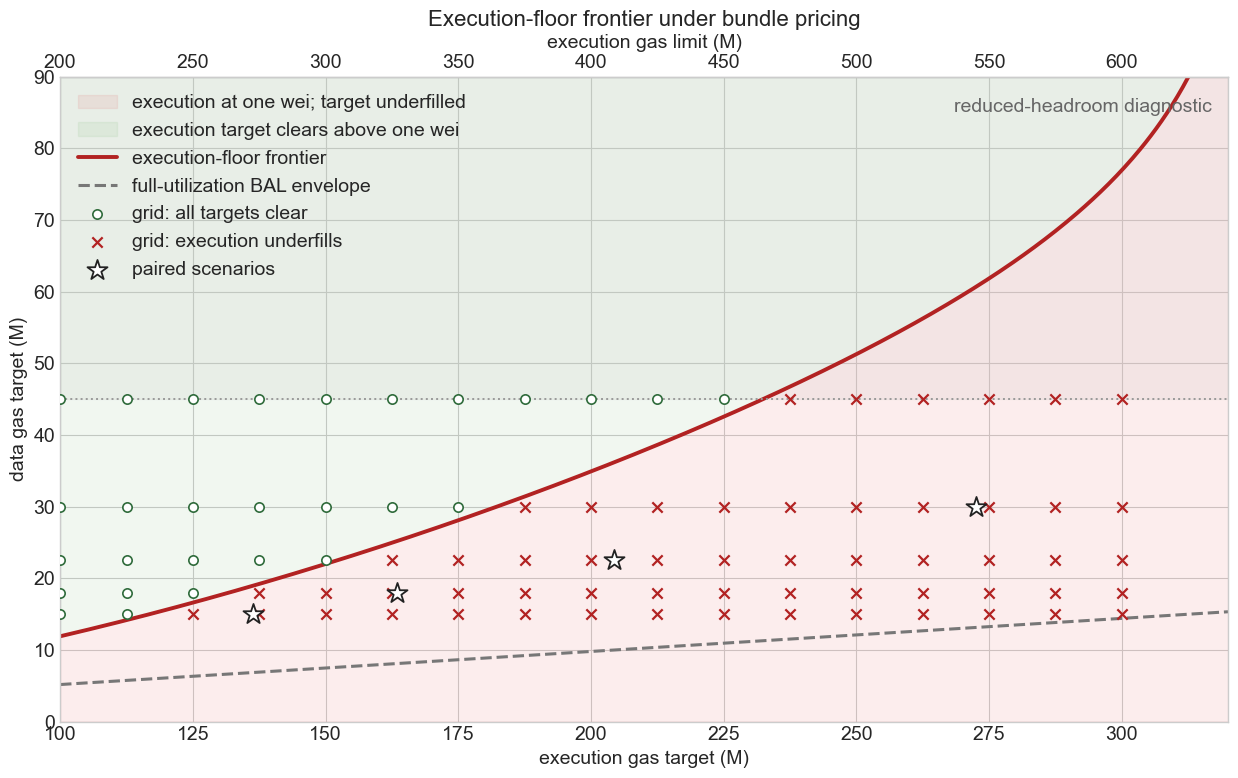

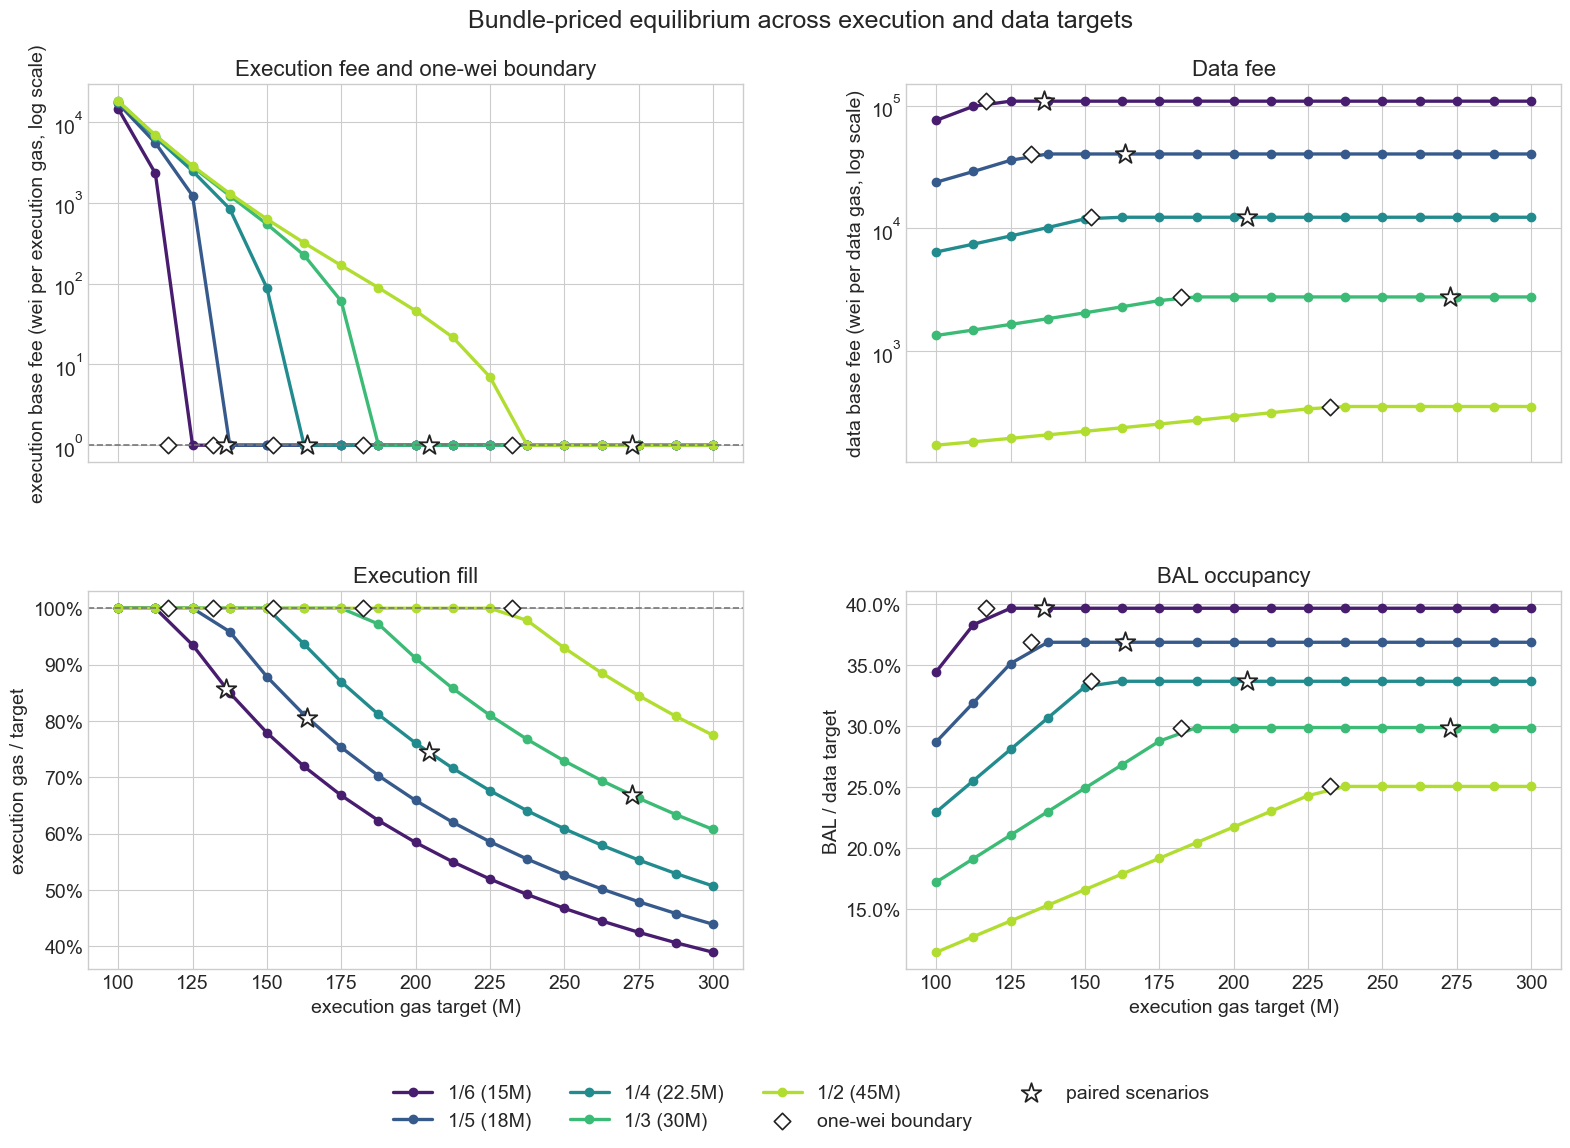

In [8]:
interior_cells = capacity_grid[~capacity_grid["execution_at_fee_floor"]]
floor_cells = capacity_grid[capacity_grid["execution_at_fee_floor"]]

fig, ax = plt.subplots(figsize=(12.6, 8.0))
frontier_x = execution_floor_frontier["execution_target"] / 1e6
frontier_y = execution_floor_frontier["data_target_at_execution_floor"] / 1e6
bal_envelope_y = execution_floor_frontier["full_utilization_bal_envelope"] / 1e6
ax.axhspan(45, 90, color="#DDDDDD", alpha=0.28, zorder=0)
ax.fill_between(
    frontier_x, 0, frontier_y, color="#E45756", alpha=0.10,
    label="execution at one wei; target underfilled",
)
ax.fill_between(
    frontier_x, frontier_y, 90, color="#54A24B", alpha=0.08,
    label="execution target clears above one wei",
)
ax.plot(
    frontier_x, frontier_y, color="#B22222", linewidth=2.8,
    label="execution-floor frontier",
)
ax.plot(
    frontier_x, bal_envelope_y, color="#777777", linestyle="--", linewidth=2.2,
    label="full-utilization BAL envelope",
)
ax.scatter(
    interior_cells["execution_target"] / 1e6,
    interior_cells["data_target"] / 1e6,
    marker="o", s=45, facecolor="white", edgecolor="#2F6B3B",
    linewidth=1.2, zorder=5, label="grid: all targets clear",
)
ax.scatter(
    floor_cells["execution_target"] / 1e6,
    floor_cells["data_target"] / 1e6,
    marker="x", s=55, color="#B22222", linewidth=1.6,
    zorder=5, label="grid: execution underfills",
)
ax.scatter(
    corner["execution_target"] / 1e6,
    corner["data_target"] / 1e6,
    marker="*", s=230, facecolor="white", edgecolor="#222222",
    linewidth=1.3, zorder=7, label="paired scenarios",
)
ax.axhline(45, color="#999999", linestyle=":", linewidth=1.4)
ax.text(317, 87, "reduced-headroom diagnostic", ha="right", va="top",
        color="#666666")
ax.set_xlim(100, 320)
ax.set_ylim(0, 90)
ax.set_xlabel("execution gas target (M)")
ax.set_ylabel("data gas target (M)")
ax.set_title("Execution-floor frontier under bundle pricing")
secondary = ax.secondary_xaxis(
    "top", functions=(lambda target: 2 * target, lambda limit: limit / 2)
)
secondary.set_xlabel("execution gas limit (M)")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig(
    PLOTS_DIR / f"bal_bundle_pricing_execution_floor_regime_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()

capacity_colors = plt.cm.viridis(
    np.linspace(0.08, 0.88, len(CAPACITY_DATA_TARGET_DENOMINATORS))
)
fig, axes = plt.subplots(2, 2, figsize=(19.0, 11.5), sharex=True)

for color, denominator in zip(
    capacity_colors, CAPACITY_DATA_TARGET_DENOMINATORS
):
    subset = capacity_grid[
        capacity_grid["data_target_denominator"].eq(denominator)
    ].sort_values("execution_target")
    target_m = subset["data_target"].iloc[0] / 1e6
    label = f"1/{denominator} ({target_m:g}M)"
    x = subset["execution_target"] / 1e6
    axes[0, 0].plot(
        x, subset["execution_fee_wei"], marker="o", linewidth=2.4,
        color=color, label=label,
    )
    axes[0, 1].plot(
        x, subset["data_fee_wei"], marker="o", linewidth=2.4, color=color,
    )
    axes[1, 0].plot(
        x, 100 * subset["execution_fill"], marker="o", linewidth=2.4,
        color=color,
    )
    axes[1, 1].plot(
        x, 100 * subset["bal_share_of_data_target"], marker="o",
        linewidth=2.4, color=color,
    )

capacity_boundary = execution_floor_boundary[
    execution_floor_boundary["data_target"].isin(capacity_grid["data_target"].unique())
]
boundary_x = capacity_boundary["execution_target_at_one_wei"] / 1e6
axes[0, 0].scatter(
    boundary_x, np.ones(len(capacity_boundary)), marker="D", s=70,
    facecolor="white", edgecolor="#222222", linewidth=1.2, zorder=6,
    label="one-wei boundary",
)
axes[0, 1].scatter(
    boundary_x, capacity_boundary["data_fee_wei_at_boundary"],
    marker="D", s=70, facecolor="white", edgecolor="#222222",
    linewidth=1.2, zorder=6,
)
axes[1, 0].scatter(
    boundary_x, np.full(len(capacity_boundary), 100.0), marker="D", s=70,
    facecolor="white", edgecolor="#222222", linewidth=1.2, zorder=6,
)
axes[1, 1].scatter(
    boundary_x, 100 * capacity_boundary["bal_share_of_data_target"],
    marker="D", s=70, facecolor="white", edgecolor="#222222",
    linewidth=1.2, zorder=6,
)

paired_x = corner["execution_target"] / 1e6
paired_style = dict(
    marker="*", s=220, facecolor="white", edgecolor="#222222",
    linewidth=1.3, zorder=7,
)
axes[0, 0].scatter(paired_x, np.ones(len(corner)), label="paired scenarios", **paired_style)
axes[0, 1].scatter(paired_x, corner["b_data (wei)"], **paired_style)
axes[1, 0].scatter(paired_x, 100 * corner["execution fill"], **paired_style)
axes[1, 1].scatter(
    paired_x, 100 * corner["BAL share of data target"], **paired_style
)

axes[0, 0].axhline(1, color="#777777", linestyle="--", linewidth=1.2)
axes[0, 0].set_yscale("log")
axes[0, 0].set_ylabel("execution base fee (wei per execution gas, log scale)")
axes[0, 0].set_title("Execution fee and one-wei boundary")

axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("data base fee (wei per data gas, log scale)")
axes[0, 1].set_title("Data fee")

axes[1, 0].axhline(100, color="#777777", linestyle="--", linewidth=1.2)
axes[1, 0].set_ylabel("execution gas / target")
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1, 0].set_title("Execution fill")

axes[1, 1].set_ylabel("BAL / data target")
axes[1, 1].yaxis.set_major_formatter(PercentFormatter(xmax=100))
axes[1, 1].set_title("BAL occupancy")

axes[1, 0].set_xlabel("execution gas target (M)")
axes[1, 1].set_xlabel("execution gas target (M)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.005),
    ncol=4, frameon=False,
)
fig.suptitle("Bundle-priced equilibrium across execution and data targets", y=0.995)
fig.subplots_adjust(hspace=0.34, wspace=0.25, top=0.93, bottom=0.16)
fig.savefig(
    PLOTS_DIR / f"bal_bundle_pricing_capacity_grid_{DATE_LABEL}.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Frontier, inverse-target, and paired-scenario sensitivity

$\lambda$ is a maintained routing assumption in this resource-based specification. The reference
case routes co-produced access through execution ($\lambda=0$); values 0.5 and 1 are structural
coupling sensitivities. Raising $\lambda$
moves BAL intensity from execution, whose activity responds to the data fee, onto state, whose
activity is pinned at its target and therefore does not.

$\rho_A$ controls how execution-linked state access changes as execution expands. Values below
one reduce BAL intensity away from the anchor; values above one increase it. The frontier
sensitivity crosses $\rho_A$, $\lambda$, and the elasticity window at data targets from
15M through 90M. Values above 45M are retained as reduced-headroom diagnostics under the fixed
90M data limit. An unconstrained point is reported separately when its implied data fee is below
one wei; such a point is not counted as an all-target-clearing protocol frontier. The separate
paired-scenario grid retains the four comparability benchmarks.

The inverse calculation fixes the execution target at 300M and solves for the minimum data
target that permits execution to clear without either base fee falling below one wei. It records
60- and 75-day cases as infeasible when the execution demand curve cannot support 300M even
before a BAL data charge is added. A controlled sensitivity then lowers only
$\epsilon_{\mathrm{execution}}$ from its 35-day value while holding the data and state
elasticities fixed.

In [9]:
def execution_target_at_data_boundary(data_target, eps, lambda_bal, rho_A):
    execution_charge_floor = m_execution * MIN_FEE_WEI / GWEI
    no_bal_ceiling = (m_execution * q_execution_0) * (
        p0 / execution_charge_floor
    ) ** eps["execution"]

    def residual(execution_target):
        frontier_data_target, _, _ = execution_clearing_data_boundary(
            execution_target, eps, lambda_bal, rho_A
        )
        return float(frontier_data_target) - data_target

    lower = max(1e6, 1e-3 * m_execution * q_execution_0)
    upper = no_bal_ceiling * (1.0 - 1e-10)
    if residual(lower) >= 0 or residual(upper) <= 0:
        raise AssertionError("failed to bracket the execution-floor frontier")
    return brentq(residual, lower, upper, xtol=1e-3, rtol=1e-12)

frontier_sensitivity_rows = []
for lambda_bal in LAMBDA_GRID:
    for rho_A in RHO_A_GRID:
        for window in WINDOW_DAYS:
            eps = EPS_BY_WINDOW[window]
            for data_target in FRONTIER_DATA_TARGETS:
                execution_target = execution_target_at_data_boundary(
                    data_target, eps, lambda_bal, rho_A
                )
                targets = {
                    "execution": execution_target,
                    "data": data_target,
                    "state": STATE_TARGET,
                }
                analytic_data, analytic_bal, analytic_fee = (
                    execution_clearing_data_boundary(
                        execution_target, eps, lambda_bal, rho_A
                    )
                )
                _, required_state_price = target_parent_prices(
                    targets, eps, lambda_bal=lambda_bal
                )
                _, w_s = intensities(lambda_bal)
                unconstrained_state_fee = (
                    required_state_price - w_s * analytic_fee / GWEI
                ) / m_state * GWEI
                data_floor_compatible = bool(
                    analytic_fee >= MIN_FEE_WEI - FEE_FEASIBILITY_ATOL_WEI
                )
                state_floor_compatible = bool(
                    unconstrained_state_fee
                    >= MIN_FEE_WEI - FEE_FEASIBILITY_ATOL_WEI
                )
                protocol_frontier_available = (
                    data_floor_compatible and state_floor_compatible
                )
                analytic_bal_execution, analytic_bal_state = bal_components(
                    execution_target / m_execution, STATE_TARGET / m_state,
                    lambda_bal, rho_A,
                )
                if not np.isclose(analytic_data, data_target, rtol=1e-9):
                    raise AssertionError("analytic frontier must reproduce the data target")
                if not np.isclose(
                    analytic_bal, analytic_bal_execution + analytic_bal_state, rtol=1e-9
                ):
                    raise AssertionError("analytic BAL components must reconcile")
                solver_diagnostics = {
                    column: np.nan for column in SOLVER_DIAGNOSTIC_COLUMNS
                }
                solved = None
                if protocol_frontier_available:
                    solved = solve_bundle(
                        targets, eps, lambda_bal=lambda_bal, rho_A=rho_A
                    )
                    if not np.isclose(
                        solved["execution_fee_wei"], MIN_FEE_WEI, atol=1e-6
                    ):
                        raise AssertionError("frontier solve must put execution at one wei")
                    for resource in RESOURCES:
                        if not np.isclose(
                            solved[f"{resource}_gas"], targets[resource],
                            rtol=1e-8, atol=1.0,
                        ):
                            raise AssertionError(
                                f"{resource} must fill at an available frontier"
                            )
                    if not np.isclose(
                        analytic_bal, solved["bal_gas"], rtol=1e-9
                    ):
                        raise AssertionError("analytic and numerical frontier BAL disagree")
                    if not np.isclose(
                        analytic_fee, solved["data_fee_wei"], rtol=1e-8
                    ):
                        raise AssertionError("analytic and numerical frontier fees disagree")
                    solver_diagnostics = {
                        column: solved[column] for column in SOLVER_DIAGNOSTIC_COLUMNS
                    }
                if not data_floor_compatible:
                    frontier_status = "unavailable: data fee below one wei"
                elif not state_floor_compatible:
                    frontier_status = "unavailable: state fee below one wei"
                else:
                    frontier_status = "available and solver-validated"
                frontier_sensitivity_rows.append({
                    "window_days": window, "lambda_bal": lambda_bal, "rho_A": rho_A,
                    "epsilon_execution": eps["execution"],
                    "epsilon_data": eps["data"],
                    "epsilon_state": eps["state"],
                    "minimum_fee_wei": MIN_FEE_WEI,
                    "data_limit": DATA_GAS_LIMIT,
                    "data_target_ratio": data_target / DATA_GAS_LIMIT,
                    "data_target": data_target, "state_target": STATE_TARGET,
                    "unconstrained_execution_target_at_one_wei": execution_target,
                    "unconstrained_corresponding_execution_limit": 2.0 * execution_target,
                    "unconstrained_data_fee_wei_at_boundary": analytic_fee,
                    "unconstrained_state_fee_wei_at_boundary": unconstrained_state_fee,
                    "data_fee_floor_compatible": data_floor_compatible,
                    "state_fee_floor_compatible": state_floor_compatible,
                    "protocol_frontier_available": protocol_frontier_available,
                    "frontier_status": frontier_status,
                    "solve_validated": solved is not None,
                    "execution_target_at_one_wei": (
                        execution_target if solved is not None else np.nan
                    ),
                    "corresponding_execution_limit": (
                        2.0 * execution_target if solved is not None else np.nan
                    ),
                    "data_fee_wei_at_boundary": (
                        solved["data_fee_wei"] if solved is not None else np.nan
                    ),
                    "state_fee_wei_at_boundary": (
                        solved["state_fee_wei"] if solved is not None else np.nan
                    ),
                    "bal_gas_at_boundary": (
                        solved["bal_gas"] if solved is not None else np.nan
                    ),
                    "bal_execution_gas_at_boundary": (
                        solved["bal_execution_gas"] if solved is not None else np.nan
                    ),
                    "bal_state_gas_at_boundary": (
                        solved["bal_state_gas"] if solved is not None else np.nan
                    ),
                    "unconstrained_bal_gas_at_boundary": analytic_bal,
                    "bal_share_of_data_target": (
                        solved["bal_gas"] / data_target
                        if solved is not None else np.nan
                    ),
                    "pinned_at_minimum": (
                        solved["pinned_at_minimum"] if solved is not None else ""
                    ),
                    **solver_diagnostics,
                })

frontier_sensitivity = pd.DataFrame(frontier_sensitivity_rows).sort_values(
    ["data_target", "window_days", "lambda_bal", "rho_A"]
).reset_index(drop=True)
expected_frontier_rows = (
    len(LAMBDA_GRID) * len(RHO_A_GRID) * len(WINDOW_DAYS)
    * len(FRONTIER_DATA_TARGETS)
)
if expected_frontier_rows != 288:
    raise AssertionError("extended frontier design must contain 288 rows")
if len(frontier_sensitivity) != expected_frontier_rows:
    raise AssertionError(f"expected {expected_frontier_rows} frontier rows")
if frontier_sensitivity.duplicated(
    ["window_days", "lambda_bal", "rho_A", "data_target"]
).any():
    raise AssertionError("frontier sensitivity contains duplicate rows")
frontier_available = frontier_sensitivity[
    frontier_sensitivity["protocol_frontier_available"]
]
frontier_unavailable = frontier_sensitivity[
    ~frontier_sensitivity["protocol_frontier_available"]
]
expected_available_by_target = {
    15e6: 36, 18e6: 36, 22.5e6: 36, 30e6: 36,
    45e6: 36, 60e6: 36, 75e6: 36, 90e6: 19,
}
available_by_target = (
    frontier_sensitivity.groupby("data_target")["protocol_frontier_available"]
    .sum().astype(int).to_dict()
)
if available_by_target != expected_available_by_target:
    raise AssertionError(
        f"unexpected protocol-frontier availability: {available_by_target}"
    )
if not frontier_available["pinned_at_minimum"].eq("execution").all():
    raise AssertionError("execution must be the only resource at an available frontier floor")
if not frontier_available["solve_validated"].all():
    raise AssertionError("every available frontier must be solver-validated")
if frontier_unavailable["solve_validated"].any():
    raise AssertionError("unavailable unconstrained points must not be treated as frontiers")
if frontier_unavailable["execution_target_at_one_wei"].notna().any():
    raise AssertionError("unavailable frontier targets must be recorded as missing")
if not (
    frontier_available.groupby(["window_days", "lambda_bal", "rho_A"])
    ["execution_target_at_one_wei"].apply(lambda x: x.is_monotonic_increasing)
).all():
    raise AssertionError("execution frontier must rise with the data target")

central_frontier_sensitivity = frontier_sensitivity[
    frontier_sensitivity["window_days"].eq(CENTRAL_WINDOW)
    & frontier_sensitivity["lambda_bal"].eq(CENTRAL_LAMBDA)
    & frontier_sensitivity["rho_A"].eq(CENTRAL_RHO_A)
].sort_values("data_target")
if not np.allclose(
    central_frontier_sensitivity["execution_target_at_one_wei"],
    execution_floor_boundary.sort_values("data_target")["execution_target_at_one_wei"],
    rtol=1e-9, atol=1.0,
):
    raise AssertionError("central sensitivity must reproduce the reference frontier")

frontier_range = frontier_available.groupby("data_target").agg(
    minimum_execution_target=("execution_target_at_one_wei", "min"),
    maximum_execution_target=("execution_target_at_one_wei", "max"),
    available_specifications=("protocol_frontier_available", "size"),
).reset_index()
range_90m = frontier_range[frontier_range["data_target"].eq(90e6)].iloc[0]
if not np.isclose(range_90m["minimum_execution_target"], 159.806806e6, atol=1.0):
    raise AssertionError("unexpected lower protocol frontier at a 90M data target")
if not np.isclose(range_90m["maximum_execution_target"], 324.188388e6, atol=1.0):
    raise AssertionError("unexpected upper protocol frontier at a 90M data target")
frontier_summary = (
    central_frontier_sensitivity[["data_target", "execution_target_at_one_wei"]]
    .rename(columns={"execution_target_at_one_wei": "central_execution_target"})
    .merge(frontier_range, on="data_target", validate="one_to_one")
)
frontier_summary_display = frontier_summary.copy()
for column in [
    "data_target", "central_execution_target",
    "minimum_execution_target", "maximum_execution_target",
]:
    frontier_summary_display[column] /= 1e6
display(frontier_summary_display)
frontier_sensitivity.to_csv(
    DATA_DIR / f"bal_bundle_pricing_execution_frontier_sensitivity_{DATE_LABEL}.csv",
    index=False,
)
frontier_sensitivity.to_csv(
    DATA_DIR / "bundle_pricing_execution_frontier_sensitivity.csv", index=False
)

FIXED_EXECUTION_TARGET = 300e6

def minimum_data_target_for_execution(
    execution_target, eps, lambda_bal, rho_A
):
    ratio = execution_target / (m_execution * q_execution_0)
    execution_charge_floor = m_execution * MIN_FEE_WEI / GWEI
    required_execution_price = p0 * ratio ** (-1.0 / eps["execution"])
    average_bal_intensity = execution_bal_intensity(
        execution_target / m_execution, lambda_bal, rho_A
    )
    maximum_data_fee_gwei = (
        required_execution_price - execution_charge_floor
    ) / average_bal_intensity
    maximum_data_fee_wei = maximum_data_fee_gwei * GWEI
    no_bal_execution_ceiling = (m_execution * q_execution_0) * (
        p0 / execution_charge_floor
    ) ** eps["execution"]
    base = {
        "execution_target": execution_target,
        "corresponding_execution_limit": 2.0 * execution_target,
        "no_bal_execution_ceiling": no_bal_execution_ceiling,
        "required_execution_parent_price_gwei": required_execution_price,
        "maximum_compatible_data_fee_wei": maximum_data_fee_wei,
    }
    if maximum_data_fee_gwei <= 0:
        return {
            **base, "protocol_feasible": False,
            "minimum_data_target": np.nan,
            "theoretical_data_target_without_data_fee_floor": np.nan,
            "full_utilization_bal_gas": np.nan,
            "infeasible_reason": (
                "execution target exceeds the zero-data-charge one-wei ceiling"
            ),
        }
    theoretical_target, full_bal, _ = execution_clearing_data_boundary(
        execution_target, eps, lambda_bal, rho_A
    )
    if maximum_data_fee_wei < MIN_FEE_WEI * (1.0 - 1e-10):
        return {
            **base, "protocol_feasible": False,
            "minimum_data_target": np.nan,
            "theoretical_data_target_without_data_fee_floor": float(
                theoretical_target
            ),
            "full_utilization_bal_gas": float(full_bal),
            "infeasible_reason": (
                "compatible data fee is below the one-wei data-fee floor"
            ),
        }
    return {
        **base, "protocol_feasible": True,
        "minimum_data_target": float(theoretical_target),
        "theoretical_data_target_without_data_fee_floor": float(
            theoretical_target
        ),
        "full_utilization_bal_gas": float(full_bal),
        "infeasible_reason": "",
    }

inverse_300_rows = []
for window in WINDOW_DAYS:
    for lambda_bal in LAMBDA_GRID:
        for rho_A in RHO_A_GRID:
            eps = EPS_BY_WINDOW[window]
            result = minimum_data_target_for_execution(
                FIXED_EXECUTION_TARGET, eps, lambda_bal, rho_A
            )
            minimum_target = result["minimum_data_target"]
            inverse_300_rows.append({
                "window_days": window, "lambda_bal": lambda_bal,
                "rho_A": rho_A, "epsilon_execution": eps["execution"],
                "epsilon_data": eps["data"],
                "epsilon_state": eps["state"],
                "minimum_fee_wei": MIN_FEE_WEI,
                "data_limit": DATA_GAS_LIMIT,
                **result,
                "minimum_data_target_ratio": (
                    minimum_target / DATA_GAS_LIMIT
                    if np.isfinite(minimum_target) else np.nan
                ),
                "within_90m_data_limit": bool(
                    np.isfinite(minimum_target)
                    and minimum_target <= DATA_GAS_LIMIT
                ),
            })
inverse_300 = pd.DataFrame(inverse_300_rows).sort_values(
    ["window_days", "lambda_bal", "rho_A"]
).reset_index(drop=True)
if len(inverse_300) != len(WINDOW_DAYS) * len(LAMBDA_GRID) * len(RHO_A_GRID):
    raise AssertionError("300M inverse grid has the wrong number of rows")
if inverse_300[inverse_300["window_days"].isin([60, 75])]["protocol_feasible"].any():
    raise AssertionError("60- and 75-day curves cannot support a 300M target")
if int(inverse_300["protocol_feasible"].sum()) != 18:
    raise AssertionError("expected 18 protocol-feasible 300M inverse specifications")
if int(inverse_300["within_90m_data_limit"].sum()) != 16:
    raise AssertionError("expected 16 300M inverse specifications within the 90M limit")
inverse_300.to_csv(
    DATA_DIR / f"bal_bundle_pricing_minimum_data_target_for_300m_execution_{DATE_LABEL}.csv",
    index=False,
)
inverse_300.to_csv(
    DATA_DIR / "bundle_pricing_minimum_data_target_for_300m_execution.csv",
    index=False,
)
display(inverse_300)

central_ratio_300 = FIXED_EXECUTION_TARGET / (m_execution * q_execution_0)
central_w_e, _ = intensities(CENTRAL_LAMBDA)
epsilon_at_data_fee_floor = (
    -np.log(central_ratio_300)
    / np.log(
        (m_execution + central_w_e) * MIN_FEE_WEI / GWEI / p0
    )
)
epsilon_at_zero_data_charge = (
    -np.log(central_ratio_300)
    / np.log(m_execution * MIN_FEE_WEI / GWEI / p0)
)
critical_data_fee_floor_drop_pct = 100 * (
    1.0 - epsilon_at_data_fee_floor / EPS["execution"]
)
critical_zero_charge_drop_pct = 100 * (
    1.0 - epsilon_at_zero_data_charge / EPS["execution"]
)

def data_target_at_execution_epsilon_drop(drop_pct):
    eps = dict(EPS)
    eps["execution"] = EPS["execution"] * (1.0 - drop_pct / 100.0)
    return minimum_data_target_for_execution(
        FIXED_EXECUTION_TARGET, eps, CENTRAL_LAMBDA, CENTRAL_RHO_A
    )

critical_data_limit_drop_pct = brentq(
    lambda drop: (
        data_target_at_execution_epsilon_drop(drop)["minimum_data_target"]
        - DATA_GAS_LIMIT
    ),
    0.0, critical_data_fee_floor_drop_pct * (1.0 - 1e-8),
)
ELASTICITY_DROP_PCT_GRID = np.array(
    [0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 3.8, 4, 5, 10, 20, 30],
    dtype=float,
)
epsilon_rows = []
for drop_pct in ELASTICITY_DROP_PCT_GRID:
    eps = dict(EPS)
    eps["execution"] = EPS["execution"] * (1.0 - drop_pct / 100.0)
    result = minimum_data_target_for_execution(
        FIXED_EXECUTION_TARGET, eps, CENTRAL_LAMBDA, CENTRAL_RHO_A
    )
    minimum_target = result["minimum_data_target"]
    epsilon_rows.append({
        "epsilon_execution_drop_percent": drop_pct,
        "epsilon_execution": eps["execution"],
        "epsilon_data_fixed": EPS["data"],
        "epsilon_state_fixed": EPS["state"],
        "window_reference_days": CENTRAL_WINDOW,
        "lambda_bal": CENTRAL_LAMBDA, "rho_A": CENTRAL_RHO_A,
        "minimum_fee_wei": MIN_FEE_WEI, "data_limit": DATA_GAS_LIMIT,
        **result,
        "within_90m_data_limit": bool(
            np.isfinite(minimum_target) and minimum_target <= DATA_GAS_LIMIT
        ),
        "critical_drop_at_90m_percent": critical_data_limit_drop_pct,
        "critical_drop_at_data_fee_floor_percent": (
            critical_data_fee_floor_drop_pct
        ),
        "zero_charge_ceiling_drop_percent": critical_zero_charge_drop_pct,
    })
execution_elasticity_sensitivity = pd.DataFrame(epsilon_rows)
central_required_data_target = execution_elasticity_sensitivity.loc[
    execution_elasticity_sensitivity["epsilon_execution_drop_percent"].eq(0),
    "minimum_data_target",
].iloc[0]
execution_elasticity_sensitivity["data_target_change_from_central"] = (
    execution_elasticity_sensitivity["minimum_data_target"]
    - central_required_data_target
)
execution_elasticity_sensitivity["data_target_change_percent"] = 100 * (
    execution_elasticity_sensitivity["minimum_data_target"]
    / central_required_data_target - 1.0
)
if not (1.9 < critical_data_limit_drop_pct < 2.1):
    raise AssertionError("90M data-limit crossing should occur near a 2% drop")
if not (3.8 < critical_data_fee_floor_drop_pct < 3.95):
    raise AssertionError("data-fee-floor crossing should occur near a 3.9% drop")
if not (4.0 < critical_zero_charge_drop_pct < 4.2):
    raise AssertionError("zero-charge ceiling should occur near a 4.1% drop")
execution_elasticity_sensitivity.to_csv(
    DATA_DIR / f"bal_bundle_pricing_execution_elasticity_sensitivity_{DATE_LABEL}.csv",
    index=False,
)
execution_elasticity_sensitivity.to_csv(
    DATA_DIR / "bundle_pricing_execution_elasticity_sensitivity.csv",
    index=False,
)
display(execution_elasticity_sensitivity)

rows = []
for rho_A in RHO_A_GRID:
    for lambda_bal in LAMBDA_GRID:
        for window in WINDOW_DAYS:
            for row in headline.itertuples(index=False):
                targets = {
                    "execution": float(row.execution_gas_limit) / 2.0,
                    "data": float(row.data_gas_target),
                    "state": STATE_TARGET,
                }
                solved = solve_bundle(
                    targets, EPS_BY_WINDOW[window], lambda_bal=lambda_bal, rho_A=rho_A
                )
                if not solved.get("solved"):
                    continue
                rows.append({
                    "rho_A": rho_A, "lambda_bal": lambda_bal, "window_days": window,
                    "data_target": targets["data"],
                    "execution_target": targets["execution"],
                    "data_fee_wei": solved["data_fee_wei"],
                    "execution_share_of_target": solved["execution_share_of_target"],
                    "bal_gas": solved["bal_gas"],
                    "bal_share_of_data_target": solved["bal_gas"] / targets["data"],
                    "execution_activity_ratio": solved["execution_activity_ratio"],
                    "effective_execution_bal_intensity": (
                        solved["effective_execution_bal_intensity"]
                    ),
                    "pinned_at_minimum": solved["pinned_at_minimum"],
                    **{column: solved[column] for column in SOLVER_DIAGNOSTIC_COLUMNS},
                })
sensitivity = pd.DataFrame(rows)
sensitivity.to_csv(DATA_DIR / f"bal_bundle_pricing_sensitivity_{DATE_LABEL}.csv", index=False)
sensitivity.to_csv(DATA_DIR / "bundle_pricing_sensitivity.csv", index=False)
central_lambda = sensitivity[
    sensitivity["window_days"].eq(CENTRAL_WINDOW)
    & sensitivity["rho_A"].eq(CENTRAL_RHO_A)
]
central_lambda_display = central_lambda.rename(columns={
    "data_fee_wei": "data base fee (wei per data gas)",
    "execution_share_of_target": "execution fill",
})
display(
    central_lambda_display.pivot_table(
        index="data_target", columns="lambda_bal",
        values=["data base fee (wei per data gas)", "execution fill"],
    )
)
central_rho = sensitivity[
    sensitivity["window_days"].eq(CENTRAL_WINDOW)
    & sensitivity["lambda_bal"].eq(CENTRAL_LAMBDA)
]
central_rho_display = central_rho.rename(columns={
    "data_fee_wei": "data base fee (wei per data gas)",
    "execution_share_of_target": "execution fill",
    "bal_share_of_data_target": "BAL share of data target",
})
display(
    central_rho_display.pivot_table(
        index="data_target", columns="rho_A",
        values=["data base fee (wei per data gas)", "execution fill",
                "BAL share of data target"],
    )
)
expected_rows = len(RHO_A_GRID) * len(LAMBDA_GRID) * len(WINDOW_DAYS) * len(headline)
if len(sensitivity) != expected_rows:
    raise AssertionError(f"expected {expected_rows} solved sensitivity rows, got {len(sensitivity)}")
frontier_classification_check = sensitivity.merge(
    frontier_sensitivity[[
        "window_days", "lambda_bal", "rho_A", "data_target",
        "execution_target_at_one_wei",
    ]],
    on=["window_days", "lambda_bal", "rho_A", "data_target"],
    how="left", validate="one_to_one",
)
frontier_classification_check["predicted_execution_floor"] = (
    frontier_classification_check["execution_target"]
    > frontier_classification_check["execution_target_at_one_wei"] * (1 + 1e-9)
)
frontier_classification_check["observed_execution_floor"] = (
    frontier_classification_check["pinned_at_minimum"].str.contains("execution")
)
if not (
    frontier_classification_check["predicted_execution_floor"]
    == frontier_classification_check["observed_execution_floor"]
).all():
    raise AssertionError("frontier and paired-scenario regime classifications disagree")
print("execution is pinned at the one-wei floor in "
      f"{sensitivity['pinned_at_minimum'].str.contains('execution').mean() * 100:.0f}% "
      "of all rho_A x lambda x window x scenario combinations")

,data_target,central_execution_target,minimum_execution_target,maximum_execution_target,available_specifications
0,15.000000,116.872708,84.176811,145.408259,36
1,18.000000,131.781465,91.775847,167.825872,36
2,22.500000,152.152916,101.746024,198.175262,36
3,30.000000,182.249933,115.669430,240.707065,36
4,45.000000,232.368813,135.886344,288.804019,36
5,60.000000,271.032541,146.370028,306.200670,36
6,75.000000,297.433749,150.101421,319.179188,36
7,90.000000,312.534083,159.806806,324.188388,19


,window_days,lambda_bal,rho_A,epsilon_execution,epsilon_data,epsilon_state,minimum_fee_wei,data_limit,execution_target,corresponding_execution_limit,no_bal_execution_ceiling,required_execution_parent_price_gwei,maximum_compatible_data_fee_wei,protocol_feasible,minimum_data_target,theoretical_data_target_without_data_fee_floor,full_utilization_bal_gas,infeasible_reason,minimum_data_target_ratio,within_90m_data_limit
0,21,0.000000,0.750000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,5.423445,True,"64,891,998.037572","64,891,998.037572","8,753,236.670135",,0.721022,True
1,21,0.000000,1.000000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,3.210096,True,"76,812,740.164939","76,812,740.164939","14,407,365.757040",,0.853475,True
2,21,0.000000,1.250000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,1.900031,True,"93,331,507.502623","93,331,507.502623","23,959,995.553858",,1.037017,False
3,21,0.500000,0.750000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,6.897858,True,"61,399,007.495188","61,399,007.495188","7,919,418.713197",,0.682211,True
4,21,0.500000,1.000000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,4.082790,True,"71,814,346.780335","71,814,346.780335","12,364,980.962006",,0.797937,True
5,21,0.500000,1.250000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,2.416572,True,"85,961,274.019263","85,961,274.019263","19,875,741.637764",,0.955125,True
6,21,1.000000,0.750000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,9.473247,True,"57,248,713.837974","57,248,713.837974","7,085,600.756259",,0.636097,True
7,21,1.000000,1.000000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,5.607143,True,"66,085,277.371157","66,085,277.371157","10,322,596.166972",,0.734281,True
8,21,1.000000,1.250000,0.117067,0.201790,0.478438,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","304,894,385.265512",0.000000,3.318825,True,"77,778,801.188725","77,778,801.188725","15,791,487.721670",,0.864209,True
9,35,0.000000,0.750000,0.121160,0.229476,0.334864,1.000000,"90,000,000.000000","300,000,000.000000","600,000,000.000000","328,281,194.052292",0.000000,40.365929,True,"64,224,559.284690","64,224,559.284690","8,753,236.670135",,0.713606,True


,epsilon_execution_drop_percent,epsilon_execution,epsilon_data_fixed,epsilon_state_fixed,window_reference_days,lambda_bal,rho_A,minimum_fee_wei,data_limit,execution_target,...,minimum_data_target,theoretical_data_target_without_data_fee_floor,full_utilization_bal_gas,infeasible_reason,within_90m_data_limit,critical_drop_at_90m_percent,critical_drop_at_data_fee_floor_percent,zero_charge_ceiling_drop_percent,data_target_change_from_central,data_target_change_percent
0,0.000000,0.121160,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"76,972,647.015548","76,972,647.015548","14,407,365.757040",,True,1.975221,3.877401,4.117729,0.000000,0.000000
1,0.500000,0.120554,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"79,506,098.215541","79,506,098.215541","14,407,365.757040",,True,1.975221,3.877401,4.117729,"2,533,451.199993",3.291366
2,1.000000,0.119948,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"82,440,052.092674","82,440,052.092674","14,407,365.757040",,True,1.975221,3.877401,4.117729,"5,467,405.077126",7.103049
3,1.500000,0.119342,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"85,929,721.635539","85,929,721.635539","14,407,365.757040",,True,1.975221,3.877401,4.117729,"8,957,074.619990",11.636698
4,2.000000,0.118736,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"90,239,048.969458","90,239,048.969458","14,407,365.757040",,False,1.975221,3.877401,4.117729,"13,266,401.953910",17.235216
5,2.500000,0.118131,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"95,869,381.535388","95,869,381.535388","14,407,365.757040",,False,1.975221,3.877401,4.117729,"18,896,734.519840",24.549935
6,3.000000,0.117525,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"103,952,815.078357","103,952,815.078357","14,407,365.757040",,False,1.975221,3.877401,4.117729,"26,980,168.062809",35.051631
7,3.500000,0.116919,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"118,007,460.912784","118,007,460.912784","14,407,365.757040",,False,1.975221,3.877401,4.117729,"41,034,813.897236",53.310904
8,3.800000,0.116556,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,"135,784,784.267946","135,784,784.267946","14,407,365.757040",,False,1.975221,3.877401,4.117729,"58,812,137.252397",76.406541
9,4.000000,0.116313,0.229476,0.334864,35,0.000000,1.000000,1.000000,"90,000,000.000000","300,000,000.000000",...,NaN,"167,430,060.667834","14,407,365.757040",compatible data fee is below the one-wei data-...,False,1.975221,3.877401,4.117729,NaN,NaN


data base fee (wei per data gas)                 \
lambda_bal                                0.000000       0.500000   
data_target                                                         
15,000,000.000000                   109,004.206737 104,548.085410   
18,000,000.000000                    40,452.529272  37,549.197160   
22,500,000.000000                    12,336.139407  11,150.475717   
30,000,000.000000                     2,764.257440   2,451.566852   

                                execution fill                    
lambda_bal             1.000000       0.000000 0.500000 1.000000  
data_target                                                       
15,000,000.000000 98,512.849380       0.857570 0.887393 0.928822  
18,000,000.000000 34,227.266303       0.805804 0.837128 0.879711  
22,500,000.000000  9,907.444935       0.744296 0.775673 0.817563  
30,000,000.000000  2,141.943576       0.668642 0.698211 0.736974

BAL share of data target                    \
rho_A                             0.750000 1.000000 1.250000   
data_target                                                    
15,000,000.000000                 0.326546 0.396683 0.463729   
18,000,000.000000                 0.295580 0.368819 0.441186   
22,500,000.000000                 0.261179 0.336868 0.414760   
30,000,000.000000                 0.221984 0.298982 0.382474   

                  data base fee (wei per data gas)                 \
rho_A                                     0.750000       1.000000   
data_target                                                         
15,000,000.000000                    67,500.831606 109,004.206737   
18,000,000.000000                    25,071.328521  40,452.529272   
22,500,000.000000                     7,702.448148  12,336.139407   
30,000,000.000000                     1,755.287069   2,764.257440   

                                 execution fill                    
rho_A                   1.250000       0.750000 1.000000 1.250000  
data_target                                                        
15,000,000.000000 182,133.922608       0.943909 0.857570 0.780386  
18,000,000.000000  68,771.954309       0.890121 0.805804 0.729226  
22,500,000.000000  21,264.479198       0.824940 0.744296 0.669689  
30,000,000.000000   4,803.705917       0.742917 0.668642 0.598123

execution is pinned at the one-wei floor in 97% of all rho_A x lambda x window x scenario combinations


In [10]:
# The execution-clearing frontier is always stricter than the full-utilisation
# BAL envelope. At a frontier point all targets clear, so parent activity is at
# full utilisation and the BAL it generates is exactly the envelope quantity;
# the same data target must additionally hold static-data demand, which is
# strictly positive at any finite data fee. Checked rather than assumed.
def envelope_execution_target(data_target, lambda_bal, rho_A):
    w_e, w_s = intensities(lambda_bal)
    room = data_target - w_s * (STATE_TARGET / m_state)
    if room <= 0:
        return 0.0
    ratio = (room / (w_e * q_execution_0)) ** (1.0 / rho_A)
    return ratio * m_execution * q_execution_0


envelope_margins = []
for row in frontier_sensitivity.itertuples(index=False):
    frontier_value = row.execution_target_at_one_wei
    if not np.isfinite(frontier_value):
        continue
    envelope_margins.append(
        envelope_execution_target(row.data_target, row.lambda_bal, row.rho_A)
        - frontier_value
    )
envelope_margins = np.asarray(envelope_margins, dtype=float)
assert (envelope_margins > 0).all(), (
    "the execution-clearing frontier must never exceed the BAL-only envelope"
)
print(
    f"envelope margin over {len(envelope_margins)} frontier points: "
    f"min {envelope_margins.min() / 1e6:.1f}M, "
    f"median {np.median(envelope_margins) / 1e6:.1f}M execution target"
)


envelope margin over 271 frontier points: min 93.8M, median 720.6M execution target


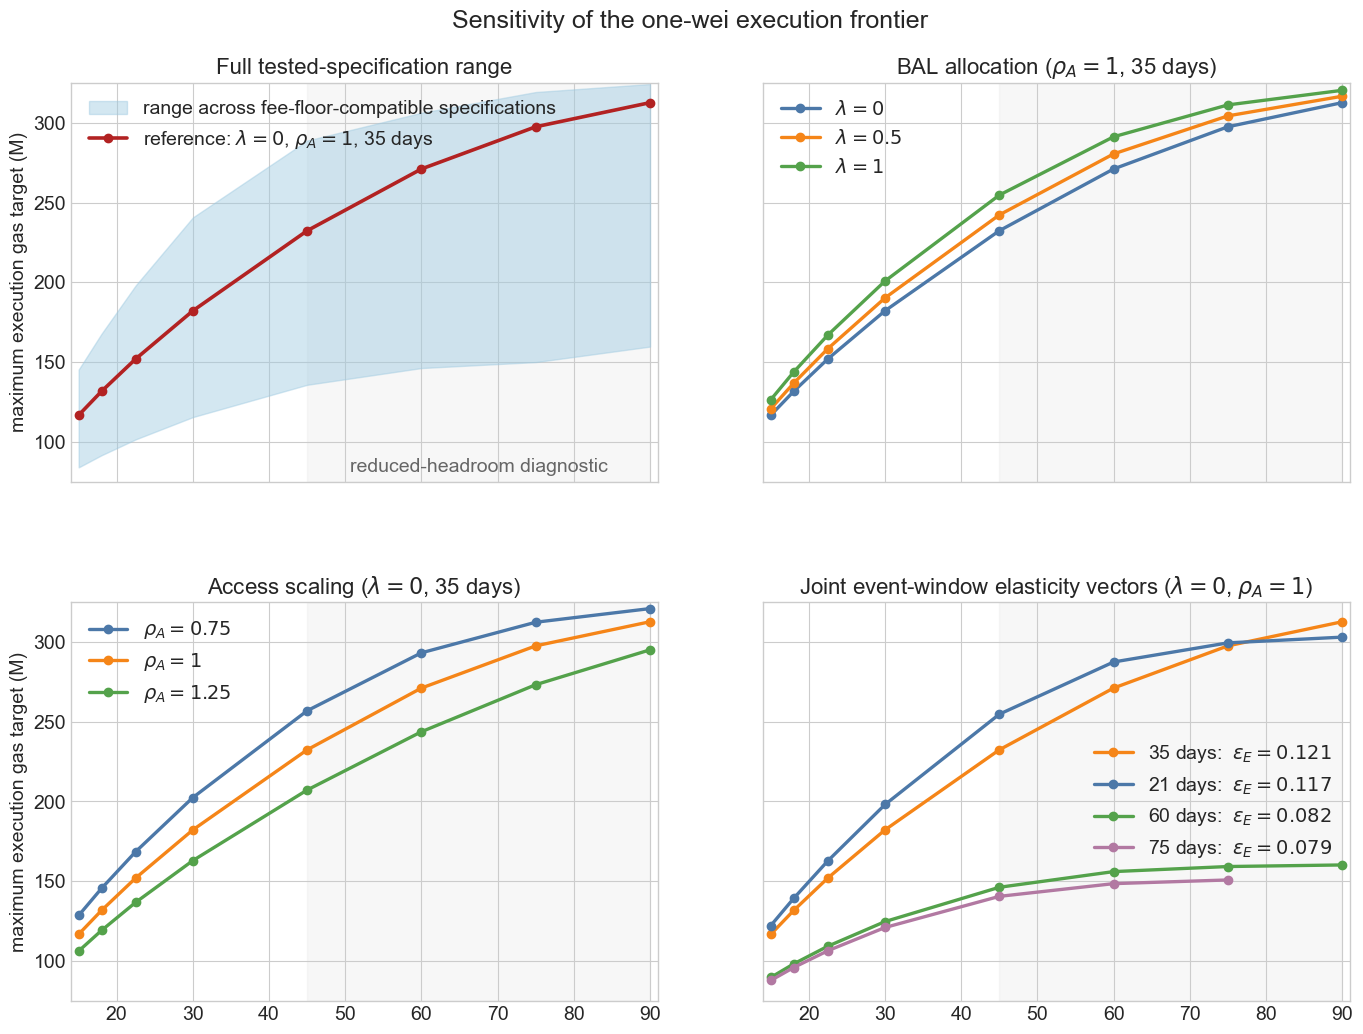

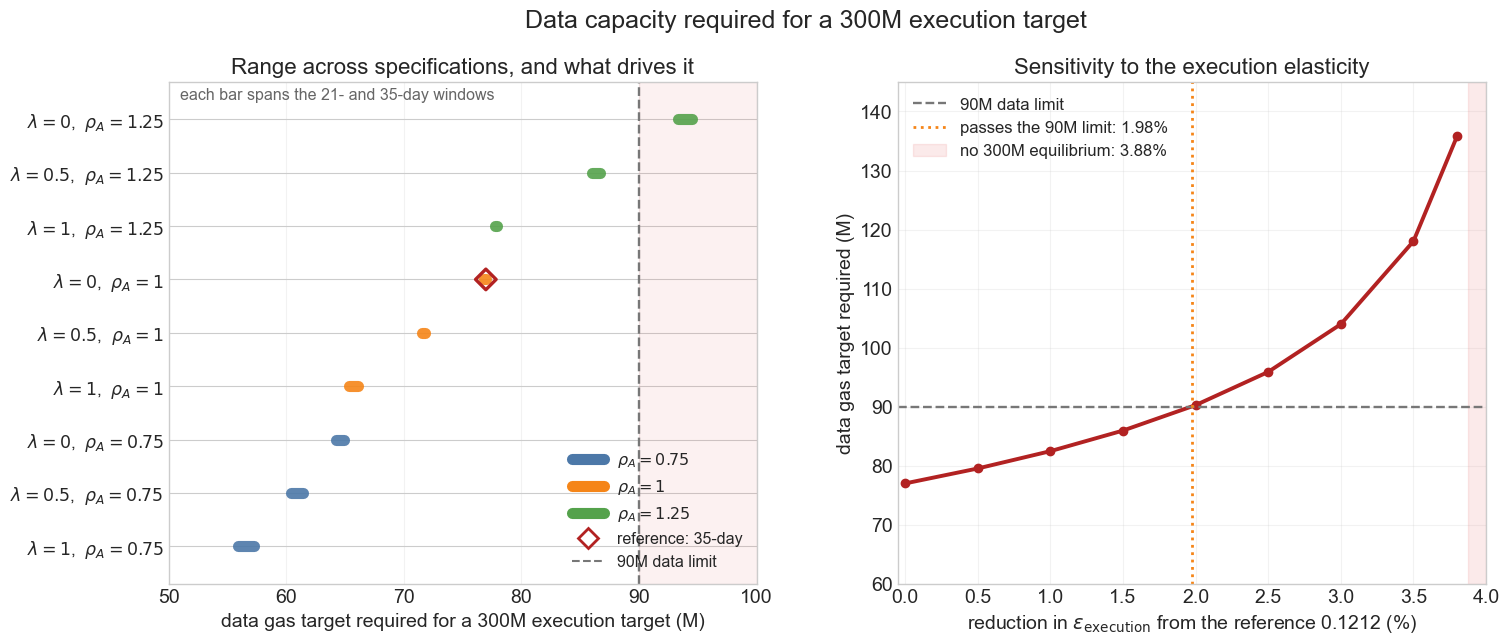

,epsilon_execution_drop_percent,epsilon_execution,data_target_for_300m_execution,data_target_change_percent,execution_target_at_90m_data,execution_target_at_45m_data,execution_change_percent,execution_change_percent_at_45m
0,0.000000,0.121200,"76,972,647.015500",0.000000,"312,534,082.982600","232,368,813.175700",0.000000,0.000000
1,0.500000,0.120600,"79,506,098.215500",3.291400,"309,316,787.652600","230,525,673.950100",-1.029400,-0.793200
2,1.000000,0.119900,"82,440,052.092700",7.103000,"306,129,757.890900","228,691,948.068100",-2.049200,-1.582300
3,1.500000,0.119300,"85,929,721.635500",11.636700,"302,972,802.005700","226,867,687.646500",-3.059300,-2.367400
4,2.000000,0.118700,"90,239,048.969500",17.235200,"299,845,726.188500","225,052,942.733400",-4.059800,-3.148400
5,2.500000,0.118100,"95,869,381.535400",24.549900,"296,748,334.664400","223,247,761.318600",-5.050900,-3.925200
6,3.000000,0.117500,"103,952,815.078400",35.051600,"293,680,429.836000","221,452,189.345800",-6.032500,-4.698000


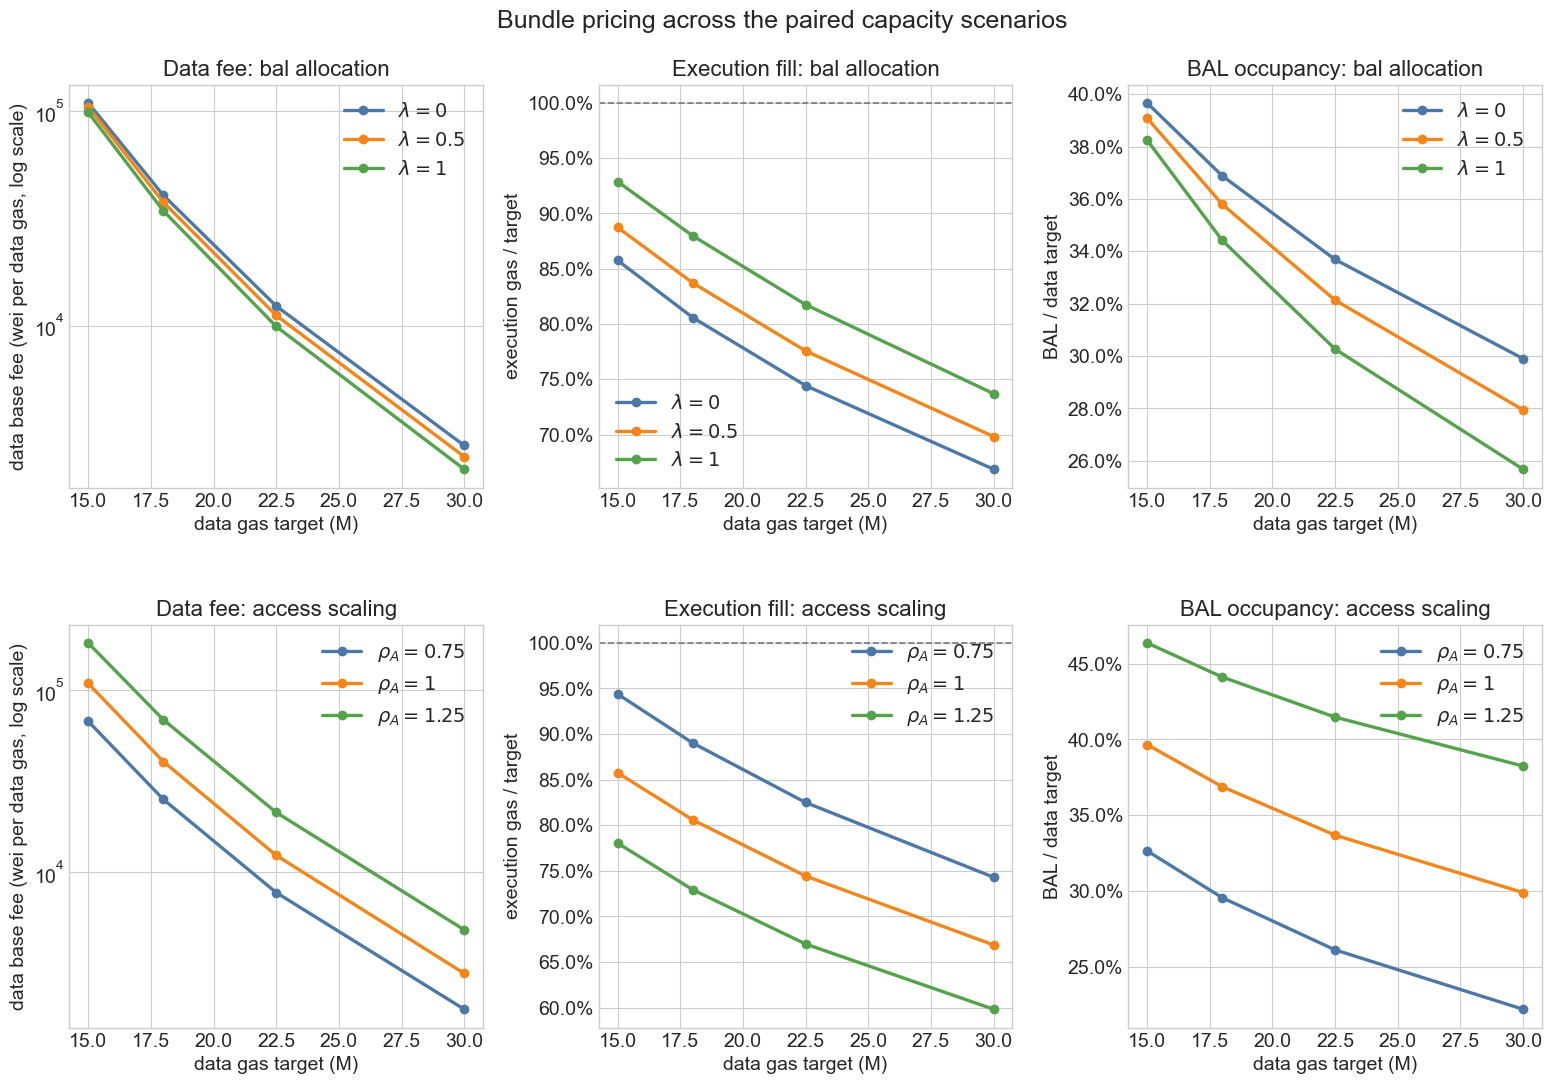

In [11]:
lambda_colors = {0.0: "#4C78A8", 0.5: "#F58518", 1.0: "#54A24B"}
rho_colors = {0.75: "#4C78A8", 1.0: "#F58518", 1.25: "#54A24B"}
window_colors = {21: "#4C78A8", 35: "#F58518", 60: "#54A24B", 75: "#B279A2"}

frontier_lambda = frontier_available[
    frontier_available["window_days"].eq(CENTRAL_WINDOW)
    & frontier_available["rho_A"].eq(CENTRAL_RHO_A)
]
frontier_rho = frontier_available[
    frontier_available["window_days"].eq(CENTRAL_WINDOW)
    & frontier_available["lambda_bal"].eq(CENTRAL_LAMBDA)
]
frontier_window = frontier_available[
    frontier_available["lambda_bal"].eq(CENTRAL_LAMBDA)
    & frontier_available["rho_A"].eq(CENTRAL_RHO_A)
]

fig, axes = plt.subplots(2, 2, figsize=(16.5, 11.2), sharex=True, sharey=True)
x_summary = frontier_summary["data_target"] / 1e6
central_300_row = inverse_300[
    inverse_300["window_days"].eq(CENTRAL_WINDOW)
    & inverse_300["lambda_bal"].eq(CENTRAL_LAMBDA)
    & inverse_300["rho_A"].eq(CENTRAL_RHO_A)
].iloc[0]
central_300_data_target_m = central_300_row["minimum_data_target"] / 1e6
axes[0, 0].fill_between(
    x_summary, frontier_summary["minimum_execution_target"] / 1e6,
    frontier_summary["maximum_execution_target"] / 1e6,
    color="#9ECAE1", alpha=0.45,
    label="range across fee-floor-compatible specifications",
)
axes[0, 0].plot(
    x_summary, frontier_summary["central_execution_target"] / 1e6,
    color="#B22222", marker="o", linewidth=2.6,
    label=r"reference: $\lambda=0$, $\rho_A=1$, 35 days",
)
axes[0, 0].set_title("Full tested-specification range")
axes[0, 0].legend(frameon=False, loc="upper left")

for lambda_bal, subset in frontier_lambda.groupby("lambda_bal"):
    subset = subset.sort_values("data_target")
    axes[0, 1].plot(
        subset["data_target"] / 1e6,
        subset["execution_target_at_one_wei"] / 1e6,
        marker="o", linewidth=2.4, color=lambda_colors[lambda_bal],
        label=rf"$\lambda={lambda_bal:g}$",
    )
axes[0, 1].set_title(r"BAL allocation ($\rho_A=1$, 35 days)")
axes[0, 1].legend(frameon=False)

for rho_A, subset in frontier_rho.groupby("rho_A"):
    subset = subset.sort_values("data_target")
    axes[1, 0].plot(
        subset["data_target"] / 1e6,
        subset["execution_target_at_one_wei"] / 1e6,
        marker="o", linewidth=2.4, color=rho_colors[rho_A],
        label=rf"$\rho_A={rho_A:g}$",
    )
axes[1, 0].set_title(r"Access scaling ($\lambda=0$, 35 days)")
axes[1, 0].legend(frameon=False)

window_order = sorted(
    frontier_window["window_days"].unique(),
    key=lambda w: -EPS_BY_WINDOW[int(w)]["execution"],
)
for window in window_order:
    subset = frontier_window[
        frontier_window["window_days"].eq(window)
    ].sort_values("data_target")
    eps_execution = EPS_BY_WINDOW[int(window)]["execution"]
    axes[1, 1].plot(
        subset["data_target"] / 1e6,
        subset["execution_target_at_one_wei"] / 1e6,
        marker="o", linewidth=2.4, color=window_colors[int(window)],
        label=rf"{int(window)} days:  $\epsilon_E={eps_execution:.3f}$",
    )
axes[1, 1].set_title(
    r"Joint event-window elasticity vectors ($\lambda=0$, $\rho_A=1$)"
)
axes[1, 1].legend(frameon=False)

frontier_y_max = frontier_available["execution_target_at_one_wei"].max() / 1e6
for ax in axes.flat:
    ax.axvspan(45, 90, color="#DDDDDD", alpha=0.22, zorder=0)
    ax.set_xlim(14, 91)
    ax.set_ylim(75, max(325, 25 * np.ceil(frontier_y_max / 25)))
axes[0, 0].text(
    67.5, axes[0, 0].get_ylim()[0] + 4,
    "reduced-headroom diagnostic", ha="center", va="bottom",
    color="#666666",
)
for ax in axes[:, 0]:
    ax.set_ylabel("maximum execution gas target (M)")
fig.suptitle("Sensitivity of the one-wei execution frontier", y=0.995)
fig.subplots_adjust(hspace=0.30, wspace=0.18, top=0.93)
fig.savefig(
    PLOTS_DIR / f"bal_bundle_pricing_execution_frontier_sensitivity_{DATE_LABEL}.png",
    dpi=180, bbox_inches="tight",
)
plt.show()

# --- Data capacity required for a 300M execution target ----------------------
# Two readings of one frontier: at a fixed 300M execution target, the data
# target it needs; and at a fixed data target, the execution it supports.
# Lowering the execution elasticity shifts the whole frontier, so both move.

EPS_DROPS_PLOTTED = (0.0, 1.0, 2.0, 3.0)


def eps_with_execution_drop(drop_pct):
    shifted = dict(EPS)
    shifted["execution"] = EPS["execution"] * (1.0 - drop_pct / 100.0)
    return shifted


elast = execution_elasticity_sensitivity
crit_90m = float(elast["critical_drop_at_90m_percent"].iloc[0])
crit_fee = float(elast["critical_drop_at_data_fee_floor_percent"].iloc[0])

frontier_grid = np.linspace(15e6, 90e6, 16)
shifted_frontiers = {}
for drop in EPS_DROPS_PLOTTED:
    eps_drop = eps_with_execution_drop(drop)
    xs, ys = [], []
    for data_target in frontier_grid:
        try:
            ys.append(
                execution_target_at_data_boundary(
                    data_target, eps_drop, CENTRAL_LAMBDA, CENTRAL_RHO_A
                ) / 1e6
            )
            xs.append(data_target / 1e6)
        except (AssertionError, ValueError):
            continue
    shifted_frontiers[drop] = (np.array(xs), np.array(ys))

# Execution supportable at a fixed data target as the elasticity falls, read at
# the 90M data limit and at a conventional one-half 45M target.
def execution_supportable_series(data_target):
    values = []
    for drop in elast["epsilon_execution_drop_percent"]:
        try:
            values.append(
                execution_target_at_data_boundary(
                    data_target, eps_with_execution_drop(float(drop)),
                    CENTRAL_LAMBDA, CENTRAL_RHO_A,
                )
            )
        except (AssertionError, ValueError):
            values.append(np.nan)
    return np.asarray(values, dtype=float)


execution_at_90m = execution_supportable_series(90e6)
execution_at_45m = execution_supportable_series(45e6)

reference_data_target = float(
    elast.loc[elast["epsilon_execution_drop_percent"].eq(0.0),
              "minimum_data_target"].iloc[0]
)
reference_execution_at_90m = float(execution_at_90m[0])

from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(17.0, 6.6))

# Panel A: the range across specifications, and which parameters drive it.
ax = axes[0]
feasible_specs = inverse_300[inverse_300["protocol_feasible"]].copy()
feasible_specs["data_M"] = feasible_specs["minimum_data_target"] / 1e6
grouped = (
    feasible_specs.groupby(["rho_A", "lambda_bal"])
    .agg(low=("data_M", "min"), high=("data_M", "max"))
    .reset_index()
    .sort_values("low")
    .reset_index(drop=True)
)
rho_palette = {0.75: "#4C78A8", 1.0: "#F58518", 1.25: "#54A24B"}
for i, row in grouped.iterrows():
    ax.plot(
        [row.low, row.high], [i, i], color=rho_palette[row.rho_A],
        linewidth=8, alpha=0.9, solid_capstyle="round",
    )
reference_value = float(
    feasible_specs[
        feasible_specs["window_days"].eq(CENTRAL_WINDOW)
        & feasible_specs["rho_A"].eq(CENTRAL_RHO_A)
        & feasible_specs["lambda_bal"].eq(CENTRAL_LAMBDA)
    ]["data_M"].iloc[0]
)
reference_row = int(
    grouped.index[
        grouped["rho_A"].eq(CENTRAL_RHO_A) & grouped["lambda_bal"].eq(CENTRAL_LAMBDA)
    ][0]
)
ax.scatter(
    [reference_value], [reference_row], marker="D", s=110, facecolor="none",
    edgecolor="#B22222", linewidth=2.4, zorder=6,
)
ax.axvline(90, color="#777777", linestyle="--", linewidth=1.7)
ax.axvspan(90, 100, color="#E45756", alpha=0.08)
ax.set_yticks(range(len(grouped)))
ax.set_yticklabels(
    [rf"$\lambda={r.lambda_bal:g}$,  $\rho_A={r.rho_A:g}$" for r in grouped.itertuples()],
    fontsize=12.5,
)
ax.set_ylim(-0.7, len(grouped) - 0.3)
ax.set_xlim(50, 100)
ax.set_xlabel("data gas target required for a 300M execution target (M)")
ax.set_title("Range across specifications, and what drives it")
ax.grid(axis="x", alpha=0.25)
handles = [
    Line2D([0], [0], color=rho_palette[r], linewidth=8, label=rf"$\rho_A={r:g}$")
    for r in (0.75, 1.0, 1.25)
] + [
    Line2D([0], [0], marker="D", linestyle="none", markerfacecolor="white",
           markeredgecolor="#B22222", markeredgewidth=2, markersize=10,
           label="reference: 35-day"),
    Line2D([0], [0], color="#777777", linestyle="--", label="90M data limit"),
]
ax.legend(handles=handles, frameon=False, loc="lower right", fontsize=11.5)
ax.annotate(
    "each bar spans the 21- and 35-day windows",
    xy=(0.02, 0.965), xycoords="axes fraction", fontsize=11.5, color="#666666",
)

# Panel B: how the reference boundary responds to the execution elasticity.
ax = axes[1]
feasible_drop = elast[elast["protocol_feasible"]]
ax.plot(
    feasible_drop["epsilon_execution_drop_percent"],
    feasible_drop["minimum_data_target"] / 1e6,
    color="#B22222", marker="o", linewidth=2.8,
)
ax.axhline(90, color="#777777", linestyle="--", linewidth=1.7, label="90M data limit")
ax.axvline(
    crit_90m, color="#F58518", linestyle=":", linewidth=2.0,
    label=f"passes the 90M limit: {crit_90m:.2f}%",
)
ax.axvspan(
    crit_fee, 4.0, color="#E45756", alpha=0.12,
    label=f"no 300M equilibrium: {crit_fee:.2f}%",
)
ax.set_xlim(-0.05, 4.0)
ax.set_ylim(60, 145)
ax.set_xlabel(
    r"reduction in $\epsilon_{\mathrm{execution}}$ from the reference 0.1212 (%)"
)
ax.set_ylabel("data gas target required (M)")
ax.set_title("Sensitivity to the execution elasticity")
ax.legend(frameon=False, loc="upper left", fontsize=12)
ax.grid(alpha=0.25)

fig.suptitle("Data capacity required for a 300M execution target", y=0.98)
fig.subplots_adjust(wspace=0.24, top=0.87)
fig.savefig(
    PLOTS_DIR / f"bal_bundle_pricing_300m_inverse_sensitivity_{DATE_LABEL}.png",
    dpi=180, bbox_inches="tight",
)
plt.show()

# Both readings of the frontier, exported together so the report can cite them.
both_boundaries = pd.DataFrame({
    "epsilon_execution_drop_percent": elast["epsilon_execution_drop_percent"].to_numpy(),
    "epsilon_execution": elast["epsilon_execution"].to_numpy(),
    "data_target_for_300m_execution": elast["minimum_data_target"].to_numpy(),
    "data_target_change_percent": elast["data_target_change_percent"].to_numpy(),
    "execution_target_at_90m_data": execution_at_90m,
    "execution_target_at_45m_data": execution_at_45m,
})
both_boundaries["execution_change_percent"] = 100 * (
    both_boundaries["execution_target_at_90m_data"] / reference_execution_at_90m - 1.0
)
both_boundaries["execution_change_percent_at_45m"] = 100 * (
    both_boundaries["execution_target_at_45m_data"] / execution_at_45m[0] - 1.0
)
both_boundaries.to_csv(
    DATA_DIR / f"bundle_pricing_300m_both_boundaries_{DATE_LABEL}.csv", index=False
)
display(both_boundaries[both_boundaries["epsilon_execution_drop_percent"] <= 3.0].round(4))

fig, axes = plt.subplots(2, 3, figsize=(19.0, 11.5))

for lambda_bal, sub in central_lambda.groupby("lambda_bal"):
    label = rf"$\lambda={lambda_bal:g}$"
    axes[0, 0].plot(sub["data_target"] / 1e6, sub["data_fee_wei"], marker="o",
                    color=lambda_colors[lambda_bal], linewidth=2.4, label=label)
    axes[0, 1].plot(sub["data_target"] / 1e6, sub["execution_share_of_target"] * 100,
                    marker="o", color=lambda_colors[lambda_bal], linewidth=2.4, label=label)
    axes[0, 2].plot(sub["data_target"] / 1e6, sub["bal_share_of_data_target"] * 100,
                    marker="o", color=lambda_colors[lambda_bal], linewidth=2.4, label=label)

for rho_A, sub in central_rho.groupby("rho_A"):
    label = rf"$\rho_A={rho_A:g}$"
    axes[1, 0].plot(sub["data_target"] / 1e6, sub["data_fee_wei"], marker="o",
                    color=rho_colors[rho_A], linewidth=2.4, label=label)
    axes[1, 1].plot(sub["data_target"] / 1e6, sub["execution_share_of_target"] * 100,
                    marker="o", color=rho_colors[rho_A], linewidth=2.4, label=label)
    axes[1, 2].plot(sub["data_target"] / 1e6, sub["bal_share_of_data_target"] * 100,
                    marker="o", color=rho_colors[rho_A], linewidth=2.4, label=label)

for row_axes, row_title in zip(axes, ("BAL allocation", "Access scaling")):
    row_axes[0].set_yscale("log")
    row_axes[0].set_ylabel("data base fee (wei per data gas, log scale)")
    row_axes[0].set_title(f"Data fee: {row_title.lower()}")
    row_axes[1].axhline(100, color="#777777", linestyle="--", linewidth=1.2)
    row_axes[1].set_ylabel("execution gas / target")
    row_axes[1].yaxis.set_major_formatter(PercentFormatter(xmax=100))
    row_axes[1].set_title(f"Execution fill: {row_title.lower()}")
    row_axes[2].set_ylabel("BAL / data target")
    row_axes[2].yaxis.set_major_formatter(PercentFormatter(xmax=100))
    row_axes[2].set_title(f"BAL occupancy: {row_title.lower()}")
    for ax in row_axes:
        ax.set_xlabel("data gas target (M)")
        ax.legend(frameon=False)

fig.suptitle("Bundle pricing across the paired capacity scenarios", y=0.995)
fig.subplots_adjust(hspace=0.34, wspace=0.28, top=0.93)
fig.savefig(PLOTS_DIR / f"bal_bundle_pricing_{DATE_LABEL}.png", dpi=180, bbox_inches="tight")
plt.show()

## Which elasticities move the boundary

The same controlled perturbation applied to each elasticity in turn, read in both
directions. State is expected to drop out entirely while it clears its target
interior: $q_{\mathrm{state}}$ is pinned at $T_{\mathrm{state}}/m_{\mathrm{state}}$
regardless of $\epsilon_{\mathrm{state}}$, so the state-linked BAL it generates is
pinned too and only $b_{\mathrm{state}}$ adjusts.


In [12]:
BOUNDARY_PERTURBATIONS = (-3.0, -2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0, 3.0)


def perturbed_eps(resource, change_pct):
    shifted = dict(EPS)
    shifted[resource] = EPS[resource] * (1.0 + change_pct / 100.0)
    return shifted


boundary_rows = []
for resource in RESOURCES:
    for change in BOUNDARY_PERTURBATIONS:
        eps_p = perturbed_eps(resource, change)
        try:
            solved = minimum_data_target_for_execution(
                300e6, eps_p, CENTRAL_LAMBDA, CENTRAL_RHO_A
            )
            data_target = (
                float(solved["minimum_data_target"])
                if solved.get("protocol_feasible", True) else np.nan
            )
        except (AssertionError, ValueError, TypeError):
            data_target = np.nan
        try:
            execution_at_90 = execution_target_at_data_boundary(
                90e6, eps_p, CENTRAL_LAMBDA, CENTRAL_RHO_A
            )
        except (AssertionError, ValueError):
            execution_at_90 = np.nan
        boundary_rows.append({
            "perturbed_resource": resource,
            "change_percent": change,
            "epsilon_value": eps_p[resource],
            "data_target_for_300m_execution": data_target,
            "execution_target_at_90m_data": execution_at_90,
        })

boundary_elasticity = pd.DataFrame(boundary_rows)
base = boundary_elasticity[boundary_elasticity["change_percent"].eq(0.0)].iloc[0]
boundary_elasticity["data_target_change_percent"] = 100 * (
    boundary_elasticity["data_target_for_300m_execution"]
    / base["data_target_for_300m_execution"] - 1.0
)
boundary_elasticity["execution_change_percent"] = 100 * (
    boundary_elasticity["execution_target_at_90m_data"]
    / base["execution_target_at_90m_data"] - 1.0
)
boundary_elasticity.to_csv(
    DATA_DIR / f"bundle_pricing_boundary_elasticity_sensitivity_{DATE_LABEL}.csv",
    index=False,
)

# Two-sided local log-elasticities from the +/-0.5% pair.
local_rows = []
for resource in RESOURCES:
    sub = boundary_elasticity[boundary_elasticity["perturbed_resource"].eq(resource)]
    hi = sub[sub["change_percent"].eq(0.5)].iloc[0]
    lo = sub[sub["change_percent"].eq(-0.5)].iloc[0]
    d_ln_eps = np.log(hi["epsilon_value"] / lo["epsilon_value"])
    local_rows.append({
        "resource": resource,
        "d_ln_data_target_d_ln_epsilon": float(
            np.log(hi["data_target_for_300m_execution"]
                   / lo["data_target_for_300m_execution"]) / d_ln_eps
        ),
        "d_ln_execution_at_90m_d_ln_epsilon": float(
            np.log(hi["execution_target_at_90m_data"]
                   / lo["execution_target_at_90m_data"]) / d_ln_eps
        ),
    })
boundary_local_elasticity = pd.DataFrame(local_rows)
display(boundary_local_elasticity.round(4))
display(
    boundary_elasticity[boundary_elasticity["change_percent"].isin((-2.0, -1.0, 1.0, 2.0))]
    .pivot(index="change_percent", columns="perturbed_resource",
           values=["data_target_change_percent", "execution_change_percent"])
    .round(3)
)


,resource,d_ln_data_target_d_ln_epsilon,d_ln_execution_at_90m_d_ln_epsilon
0,execution,-6.180300,2.068500
1,data,2.746000,-0.606300
2,state,0.000000,0.000000


data_target_change_percent                     \
perturbed_resource                       data execution    state   
change_percent                                                     
-2.000000                           -5.311000 17.235000 0.000000   
-1.000000                           -2.700000  7.103000 0.000000   
1.000000                             2.793000 -5.492000 0.000000   
2.000000                             5.682000 -9.987000 0.000000   

                   execution_change_percent                     
perturbed_resource                     data execution    state  
change_percent                                                  
-2.000000                          1.124000 -4.060000 0.000000  
-1.000000                          0.584000 -2.049000 0.000000  
1.000000                          -0.628000  2.088000 0.000000  
2.000000                          -1.297000  4.216000 0.000000

## What this establishes

The current full-precision solve verifies the incidence lemma, the fee-floor complementarity
conditions, and the execution-target dropout property. Every report-facing solve evaluates all
eight pin sets and retains one economically distinct equilibrium.

Four results carry into the report:

1. **The reference paired equilibria are corner solutions.** At $\rho_A=1$, every pairing requires a
   negative execution fee in the fully interior calculation. At the one-wei floor, execution reaches
   only 67--86% of target.
2. **The execution target drops out at the fee floor.** With execution at one wei, the configured
   execution target no longer enters the data-market condition. The 600M/15M cell therefore has
   the same equilibrium as the 272.6M/15M cell.
3. **Access intensity matters for the numerical equilibrium.** With $\lambda=0$ and the 35-day
   elasticities, $\rho_A=0.75$ gives data base fees of 1,755--67,501 wei per data gas and
   execution fills of 74.3--94.4%; $\rho_A=1.25$ gives 4,804--182,134 wei per data gas and
   fills of 59.8--78.0%. The reference
   $\lambda=0$ cases remain at the execution floor for every $\rho_A$ and event window. Across the
   complete $\rho_A\times\lambda\times\text{window}\times\text{scenario}$ grid, 140 of 144
   cases reach the floor; the four interior cases all use $\rho_A=0.75$ and $\lambda>0$.
4. **The execution-clearing frontier is the main capacity result.** It reports the largest
   execution target that can be fully used without requiring a fee below one wei. Across the
   36 tested specifications, the frontier ranges from 84.2M to 145.4M at a 15M data target
   and from 135.9M to 288.8M at a 45M data target. The paired-scenario floor classification is
   stable, while the numerical frontier is sensitive, particularly to the event window.

The $\rho_A$ range tests how the activity mix changes as execution expands; it is not an estimated
demand elasticity. Because the calculation extrapolates isoelastic demand beyond the historical
support, regime classifications in the reference model are more stable than
the wei-level fees.

## Report output and numerical verification

This final cell reads the seven report-facing CSVs, verifies them against the in-memory results,
checks the eight-active-set uniqueness diagnostics, and prints the three markdown-ready headline
tables. The generated tables are the source for report values.


In [13]:
report_paired = pd.read_csv(DATA_DIR / "bundle_pricing_paired_equilibria.csv")
report_frontier = pd.read_csv(DATA_DIR / "bundle_pricing_execution_frontier.csv")
report_frontier_sensitivity = pd.read_csv(
    DATA_DIR / "bundle_pricing_execution_frontier_sensitivity.csv"
)
report_capacity = pd.read_csv(DATA_DIR / "bundle_pricing_capacity_grid.csv")
report_sensitivity = pd.read_csv(DATA_DIR / "bundle_pricing_sensitivity.csv")
report_inverse_300 = pd.read_csv(
    DATA_DIR / "bundle_pricing_minimum_data_target_for_300m_execution.csv"
)
report_execution_elasticity = pd.read_csv(
    DATA_DIR / "bundle_pricing_execution_elasticity_sensitivity.csv"
)

def _assert_numeric_export(exported, source, columns, label):
    if len(exported) != len(source):
        raise AssertionError(f"{label} export row count changed")
    for column in columns:
        if not np.allclose(
            exported[column].to_numpy(dtype=float),
            source[column].to_numpy(dtype=float),
            rtol=1e-12, atol=1e-6, equal_nan=True,
        ):
            raise AssertionError(f"{label} export disagrees in {column}")

_assert_numeric_export(
    report_paired, paired_equilibria_export,
    ["execution_target", "data_target", "data_base_fee_wei_per_data_gas",
     "execution_gas", "execution_fill", "bal_gas",
     "bal_share_of_data_target", "state_base_fee_wei_per_state_gas"],
    "paired equilibria",
)
_assert_numeric_export(
    report_frontier, execution_floor_boundary,
    ["data_target", "execution_target_at_one_wei",
     "corresponding_execution_limit", "data_fee_wei_at_boundary"],
    "execution frontier",
)
_assert_numeric_export(
    report_frontier_sensitivity, frontier_sensitivity,
    ["window_days", "lambda_bal", "rho_A", "data_target",
     "execution_target_at_one_wei", "data_fee_wei_at_boundary",
     "state_fee_wei_at_boundary", "bal_gas_at_boundary",
     "unconstrained_execution_target_at_one_wei",
     "unconstrained_data_fee_wei_at_boundary"],
    "execution frontier sensitivity",
)
for column in [
    "data_fee_floor_compatible", "state_fee_floor_compatible",
    "protocol_frontier_available", "solve_validated", "frontier_status",
]:
    if not report_frontier_sensitivity[column].equals(
        frontier_sensitivity[column]
    ):
        raise AssertionError(
            f"execution frontier sensitivity export disagrees in {column}"
        )
_assert_numeric_export(
    report_capacity, capacity_grid,
    ["execution_target", "data_target", "execution_fee_wei",
     "data_fee_wei", "execution_fill", "bal_gas"],
    "capacity grid",
)
_assert_numeric_export(
    report_sensitivity, sensitivity,
    ["rho_A", "lambda_bal", "window_days", "data_target",
     "execution_target", "data_fee_wei", "execution_share_of_target"],
    "sensitivity grid",
)
_assert_numeric_export(
    report_inverse_300, inverse_300,
    ["window_days", "lambda_bal", "rho_A",
     "minimum_data_target", "maximum_compatible_data_fee_wei",
     "no_bal_execution_ceiling"],
    "300M inverse target",
)
_assert_numeric_export(
    report_execution_elasticity, execution_elasticity_sensitivity,
    ["epsilon_execution_drop_percent", "epsilon_execution",
     "minimum_data_target", "maximum_compatible_data_fee_wei",
     "critical_drop_at_90m_percent",
     "critical_drop_at_data_fee_floor_percent"],
    "controlled execution-elasticity sensitivity",
)

verification_frames = {
    "paired": report_paired, "frontier": report_frontier,
    "frontier sensitivity": report_frontier_sensitivity,
    "capacity": report_capacity, "sensitivity": report_sensitivity,
}
verification_rows = []
for label, frame in verification_frames.items():
    solver_frame = frame
    if "solve_validated" in frame.columns:
        if not (
            frame["solve_validated"].astype(bool)
            == frame["protocol_frontier_available"].astype(bool)
        ).all():
            raise AssertionError(
                f"{label} compatibility and solver-validation flags disagree"
            )
        solver_frame = frame[frame["solve_validated"].astype(bool)]
    if not solver_frame["evaluated_pin_sets"].eq(8).all():
        raise AssertionError(f"{label} contains a solve that did not evaluate eight pin sets")
    if not solver_frame["unique_economic_equilibria"].eq(1).all():
        raise AssertionError(f"{label} contains a non-unique economic equilibrium")
    verification_rows.append({
        "output": label,
        "rows": len(frame),
        "solver-validated rows": len(solver_frame),
        "max interior target residual (gas)": (
            solver_frame["max_interior_target_residual_gas"].max()
        ),
        "max interior target residual (relative)": (
            solver_frame["max_interior_target_residual_relative"].max()
        ),
        "max complementarity residual (wei per block)": (
            solver_frame["max_complementarity_residual_wei_per_block"].max()
        ),
        "minimum free-fee distance above one wei": (
            solver_frame["minimum_free_fee_distance_above_one_wei"].min()
        ),
    })
verification_summary = pd.DataFrame(verification_rows)
display(verification_summary)

print("\nMarkdown-ready paired-scenario table:\n")
print("| $T_E$ | $T_D$ | Regime | Data base fee (wei / data gas) | Execution fill | BAL share |")
print("|---:|---:|---|---:|---:|---:|")
for _, row in report_paired.sort_values("data_target").iterrows():
    regime = ("$b_E=1$ wei" if row["pinned_resource_set"] == "execution"
              else "all targets clear")
    print(
        f"| {row['execution_target'] / 1e6:.1f}M | {row['data_target'] / 1e6:g}M | "
        f"{regime} | {row['data_base_fee_wei_per_data_gas']:,.0f} | "
        f"{row['execution_fill']:.2%} | {row['bal_share_of_data_target']:.2%} |"
    )

print("\nMarkdown-ready execution-frontier table:\n")
print("| Data target | Maximum execution target at the one-wei boundary |")
print("|---:|---:|")
for row in report_frontier.sort_values("data_target").itertuples(index=False):
    print(
        f"| {row.data_target / 1e6:g}M | "
        f"{row.execution_target_at_one_wei / 1e6:.1f}M |"
    )

print("\nMarkdown-ready frontier-sensitivity table:\n")
print("| Data target | Reference frontier | Protocol-compatible range | Available |")
print("|---:|---:|---:|---:|")
for row in frontier_summary.itertuples(index=False):
    print(
        f"| {row.data_target / 1e6:g}M | "
        f"{row.central_execution_target / 1e6:.1f}M | "
        f"{row.minimum_execution_target / 1e6:.1f}--"
        f"{row.maximum_execution_target / 1e6:.1f}M | "
        f"{int(row.available_specifications)}/36 |"
    )

print("\nMarkdown-ready 300M inverse-target table:\n")
print("| Elasticity window | Minimum data target across allocation/access cases | Status |")
print("|---:|---:|---|")
for window in WINDOW_DAYS:
    subset = report_inverse_300[report_inverse_300["window_days"].eq(window)]
    feasible = subset[subset["protocol_feasible"]]
    if feasible.empty:
        ceiling = subset["no_bal_execution_ceiling"].max() / 1e6
        print(f"| {window} days | -- | infeasible; no-BAL ceiling {ceiling:.1f}M |")
    else:
        print(
            f"| {window} days | {feasible['minimum_data_target'].min() / 1e6:.2f}--"
            f"{feasible['minimum_data_target'].max() / 1e6:.2f}M | feasible cases |"
        )

print("\nControlled 35-day execution-elasticity thresholds:\n")
print(f"90M data limit crossed after a {critical_data_limit_drop_pct:.3f}% reduction")
print(
    "300M becomes infeasible at the one-wei data-fee floor after a "
    f"{critical_data_fee_floor_drop_pct:.3f}% reduction"
)
print("\nAll report-facing outputs match the executed notebook; every recorded solve has one unique equilibrium.")


,output,rows,solver-validated rows,max interior target residual (gas),max interior target residual (relative),max complementarity residual (wei per block),minimum free-fee distance above one wei
0,paired,4,4,0.000000,0.000000,0.017650,"2,763.257440"
1,frontier,8,8,0.000000,0.000000,0.017650,9.835115
2,frontier sensitivity,288,271,0.000000,0.000000,0.081057,0.028003
3,capacity,85,85,0.000001,0.000000,0.035300,5.976964
4,sensitivity,144,144,0.000000,0.000000,0.081056,43.222476



Markdown-ready paired-scenario table:

| $T_E$ | $T_D$ | Regime | Data base fee (wei / data gas) | Execution fill | BAL share |
|---:|---:|---|---:|---:|---:|
| 136.3M | 15M | $b_E=1$ wei | 109,004 | 85.76% | 39.67% |
| 163.5M | 18M | $b_E=1$ wei | 40,453 | 80.58% | 36.88% |
| 204.4M | 22.5M | $b_E=1$ wei | 12,336 | 74.43% | 33.69% |
| 272.6M | 30M | $b_E=1$ wei | 2,764 | 66.86% | 29.90% |

Markdown-ready execution-frontier table:

| Data target | Maximum execution target at the one-wei boundary |
|---:|---:|
| 15M | 116.9M |
| 18M | 131.8M |
| 22.5M | 152.2M |
| 30M | 182.2M |
| 45M | 232.4M |
| 60M | 271.0M |
| 75M | 297.4M |
| 90M | 312.5M |

Markdown-ready frontier-sensitivity table:

| Data target | Reference frontier | Protocol-compatible range | Available |
|---:|---:|---:|---:|
| 15M | 116.9M | 84.2--145.4M | 36/36 |
| 18M | 131.8M | 91.8--167.8M | 36/36 |
| 22.5M | 152.2M | 101.7--198.2M | 36/36 |
| 30M | 182.2M | 115.7--240.7M | 36/36 |
| 45M | 232.4M | 135.9--288.8M | 36/36